In [11]:
# Title: 02_Ripa_PCR.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the PCR clock on Ripa et al

# Set-Up

In [12]:
import os
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.stats import poisson
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
lowess = sm.nonparametric.lowess
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import ttest_ind, mannwhitneyu
import random
import itertools

In [13]:
import os
os.chdir("/labs/twc/Emma/atlas_gdrive_backup/revisions/CodeCheck_revisions/Ripa_model_outputs/PCR/")

In [14]:
palette = sns.color_palette("deep")
hex_codes = palette.as_hex()

print(hex_codes)

['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860', '#da8bc3', '#8c8c8c', '#ccb974', '#64b5cd']


In [15]:
# List of directories you want to create
dirs_to_create = [
    "./reference/",
    "./predictions/",
    "./gene_sets/",
    "./plots/",
    "./predictions_exhaustive/",
    "./reference_exhaustive/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

### Load data

In [16]:
df_norm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

In [17]:
df_norm = df_norm.T

In [18]:
df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,913.804009,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,774.447946,64.653195,670.168600,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,520.497299,128.487541,1351.165159,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,1201.386683,131.470142,800.089724,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,420.973787,192.365505,1129.101879,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940


In [19]:
df_norm_frequency = df_norm.div(df_norm.sum(axis=1), axis=0)

In [20]:
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [21]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [22]:
df_metadata.set_index("sample", inplace=True)

In [23]:
# Merge based on index
combined_df = pd.concat([df_norm_frequency, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

In [24]:
combined_df["tissue"].value_counts()

Gut           55
Kidney        55
Muscle        55
Spleen        55
SpinalCord    54
Heart         54
Skin          54
Brain         54
Liver         54
Fat           53
Bone          51
Eye           37
Testis        31
Ovary         15
Name: tissue, dtype: int64

In [25]:
df_norm_metadata = pd.concat([df_norm, df_metadata[["sex", "tissue", "age_days"]]], axis=1)

df_norm_metadata.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47


In [26]:
#function to load norm counts
def load_intervention_countdata(tissue):
    file_path = f"../../Data_from_Others/Antebi_Fat_Ripa_etal_2023/CountsNormDESeq2_AntebiFat_250605.csv"
    return pd.read_csv(file_path)

#function to load metadata
def load_intervention_metadata(tissue):
    file_path = f"../../Data_from_Others/Antebi_Fat_Ripa_etal_2023/ExperimentDesign_AntebiFat_update_20250629.csv"
    return pd.read_csv(file_path)

In [27]:
select_tissue = 'Fat'

In [28]:
#load intervention data
df_intervention = load_intervention_countdata(select_tissue)
df_intervention.head(5)

,Unnamed: 0,young_fed_wt_fat_rep_4,young_fasted_wt_fat_rep_1,young_fasted_wt_fat_rep_2,young_fasted_wt_fat_rep_3,young_fasted_wt_fat_rep_4,young_fed_mut_fat_rep_1,young_fed_mut_fat_rep_2,old_fed_wt_fat_rep_4,young_fed_mut_fat_rep_3,...,old_fasted_mut_fat_rep_3,old_fasted_mut_fat_rep_2,old_fasted_mut_fat_rep_1,old_fed_mut_fat_rep_5,old_fed_mut_fat_rep_4,old_fed_mut_fat_rep_3,old_fed_mut_fat_rep_2,old_fed_mut_fat_rep_1,old_fed_wt_fat_rep_2,old_fed_wt_fat_rep_1
0,LOC107389033,36.053243,72.526712,49.392975,78.809091,67.473420,107.261815,69.336963,287.925564,87.207925,...,231.054531,252.187117,115.224356,93.909833,145.647969,129.180120,91.235722,139.159652,273.443432,228.423958
1,LOC107383083,0.000000,9.460006,0.000000,2.814610,8.434177,11.290717,0.000000,0.000000,2.076379,...,5.705050,18.880319,19.338354,0.000000,6.132546,18.631748,13.617272,3.115515,3.811058,2.864250
2,LOC107396907,18.026622,60.701705,66.425035,77.401786,74.501901,183.474157,137.903515,140.292343,115.239044,...,184.273120,128.116450,82.993767,58.197643,154.846788,80.737575,125.278901,114.235536,212.466499,90.223883
3,LOC107392678,9.013311,18.920012,17.032060,8.443831,22.491140,11.290717,13.867393,14.681757,10.381896,...,21.108686,24.274696,12.892236,5.290695,12.265092,24.842331,19.064181,16.616078,23.819114,12.889126
4,LOC107395313,33.799916,31.533353,37.470533,49.255682,36.548102,38.106171,33.898071,34.257433,25.954740,...,35.371311,29.669073,55.597766,40.341548,52.893210,40.989846,32.681453,33.751408,34.299525,30.790690


In [29]:
#load intervention metadata
df_intervention_metadata = load_intervention_metadata(select_tissue)
df_intervention_metadata.set_index("Sample.Name", inplace=True)
print(df_intervention_metadata.head(1))

                                Run              AGE Assay.Type  AvgSpotLen  \
Sample.Name                                                                   
young_fed_wt_fat_rep_4  SRR18362991  Young (7 weeks)    RNA-Seq         202   

                             Bases   BioProject     BioSample  \
Sample.Name                                                     
young_fed_wt_fat_rep_4  6623920370  PRJNA817434  SAMN26788046   

                                  BioSampleModel       Bytes  \
Sample.Name                                                    
young_fed_wt_fat_rep_4  Model organism or animal  1964305779   

                                                       Center.Name  ...  \
Sample.Name                                                         ...   
young_fed_wt_fat_rep_4  MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING  ...   

                                 ReleaseDate           create_date version  \
Sample.Name                                                          

### Reformat Data

In [30]:
#reformat intervention dataset
df_intervention.rename(columns={"Unnamed: 0": "Sample.Name"}, inplace=True)
df_intervention.set_index("Sample.Name", inplace=True)
df_intervention = df_intervention.T
df_intervention.head(3)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107397194,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,286.172618,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,359.480226,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699
young_fasted_wt_fat_rep_2,49.392975,0.000000,66.425035,17.032060,37.470533,10.219236,218.010373,117.521217,124.334041,456.459218,...,488.820133,1161.586518,0.000000,0.000000,68.128242,139.662895,911.215230,614.857380,124.334041,10.219236


In [31]:
# remove outliers - not needed
#df_intervention = df_intervention.drop('spleen_6')
# remove outliers
#df_intervention_metadata = df_intervention_metadata.drop('spleen_6')

In [32]:
df_intervention_age = df_intervention.copy()

In [33]:
#reformat intervention metadata
df_intervention_metadata['tissue'] = df_intervention_metadata['tissue'].replace('Visceral adipose tissue', 'Fat')

In [34]:
df_intervention_metadata = df_intervention_metadata[df_intervention_metadata["tissue"] == select_tissue]
df_intervention_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,...,ReleaseDate,create_date,version,sex,SRA.Study,strain,tissue,file,lib,UsedForTraining
Sample.Name,,,,,,,,,,,,,,,,,,,,,
young_fed_wt_fat_rep_4,SRR18362991,Young (7 weeks),RNA-Seq,202,6623920370,PRJNA817434,SAMN26788046,Model organism or animal,1964305779,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,2022-03-20T00:00:00Z,2022-03-20T03:18:00Z,1,male,SRP364776,GRZ_AD wild_type,Fat,SRR18362991.featureCounts,SRR18362991,Yes
young_fasted_wt_fat_rep_1,SRR18362992,Young (7 weeks),RNA-Seq,202,7410627954,PRJNA817434,SAMN26788047,Model organism or animal,2234922451,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,2022-03-20T00:00:00Z,2022-03-20T03:46:00Z,1,male,SRP364776,GRZ_AD wild_type,Fat,SRR18362992.featureCounts,SRR18362992,No
young_fasted_wt_fat_rep_2,SRR18362993,Young (7 weeks),RNA-Seq,202,6127879272,PRJNA817434,SAMN26788048,Model organism or animal,1868755404,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,2022-03-20T00:00:00Z,2022-03-20T03:13:00Z,1,male,SRP364776,GRZ_AD wild_type,Fat,SRR18362993.featureCounts,SRR18362993,No
young_fasted_wt_fat_rep_3,SRR18362994,Young (7 weeks),RNA-Seq,202,7087796402,PRJNA817434,SAMN26788049,Model organism or animal,2137039468,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,2022-03-20T00:00:00Z,2022-03-20T03:58:00Z,1,male,SRP364776,GRZ_AD wild_type,Fat,SRR18362994.featureCounts,SRR18362994,No
young_fasted_wt_fat_rep_4,SRR18362995,Young (7 weeks),RNA-Seq,202,6103246988,PRJNA817434,SAMN26788050,Model organism or animal,1833695494,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,2022-03-20T00:00:00Z,2022-03-20T03:22:00Z,1,male,SRP364776,GRZ_AD wild_type,Fat,SRR18362995.featureCounts,SRR18362995,No


In [35]:
#list the column names
#list(df_intervention_metadata.columns.values)

In [36]:
df_intervention_age = df_intervention_age.loc[df_intervention_metadata.index.tolist(),]

df_intervention_age.head(5)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107397194,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,286.172618,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,359.480226,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699
young_fasted_wt_fat_rep_2,49.392975,0.000000,66.425035,17.032060,37.470533,10.219236,218.010373,117.521217,124.334041,456.459218,...,488.820133,1161.586518,0.000000,0.000000,68.128242,139.662895,911.215230,614.857380,124.334041,10.219236
young_fasted_wt_fat_rep_3,78.809091,2.814610,77.401786,8.443831,49.255682,2.814610,208.281169,92.882143,121.028247,343.382468,...,454.559578,1007.630519,0.000000,0.000000,111.177110,95.696753,966.818669,640.323864,177.320455,84.438312
young_fasted_wt_fat_rep_4,67.473420,8.434177,74.501901,22.491140,36.548102,5.622785,220.694310,113.861396,116.672788,479.342419,...,323.310136,974.147497,0.000000,4.217089,53.416457,108.238611,833.577873,463.879761,164.466461,30.925317


In [37]:
#select tissue from atlas dataset
tissue_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == select_tissue]
tissue_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,M,Fat,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,M,Fat,77
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,F,Fat,78
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,M,Fat,103
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530,F,Fat,134


In [38]:
tissue_df_age = tissue_df_norm.drop(tissue_df_norm.columns[[-2, -3]], axis=1)
tissue_df_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age_days
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,77


In [39]:
df_intervention_age["tissue"] = df_intervention_metadata["tissue"].tolist()
df_intervention_age["AGE"] = df_intervention_metadata["AGE"].tolist()
df_intervention_age["sex"] = df_intervention_metadata["sex"].tolist()
df_intervention_age["training"] = df_intervention_metadata["UsedForTraining"].tolist()
df_intervention_age["genotype"] = df_intervention_metadata["strain"].tolist()


age_mapping = {
    "Young (7 weeks)": 49,
    "Old (18 weeks)": 126
}

df_intervention_age["age"] = df_intervention_age["AGE"].map(age_mapping)

df_intervention_age.head(3)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,ddx42,LOC107381819,srek1ip1,LOC107388320,tissue,AGE,sex,training,genotype,age
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,883.304459,554.318615,290.679273,15.773294,Fat,Young (7 weeks),male,Yes,GRZ_AD wild_type,49
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,789.122163,346.078551,223.098474,51.241699,Fat,Young (7 weeks),male,No,GRZ_AD wild_type,49
young_fasted_wt_fat_rep_2,49.392975,0.000000,66.425035,17.032060,37.470533,10.219236,218.010373,117.521217,124.334041,456.459218,...,911.215230,614.857380,124.334041,10.219236,Fat,Young (7 weeks),male,No,GRZ_AD wild_type,49


In [40]:
df_intervention_age_counts = df_intervention_age.iloc[:,:-6]

df_intervention_age_counts.head(2)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107397194,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,286.172618,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,359.480226,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699


In [41]:
#load atlas
tissue_df_age = tissue_df_age.rename(columns={'age_days': 'age'})
tissue_df_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,77


In [42]:
#load intervention
df_intervention_age_only = df_intervention_age.drop(df_intervention_age.columns[[-1,-2,-3, -4,-6]], axis=1)
df_intervention_age_only.head(2)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320,AGE
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294,Young (7 weeks)
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699,Young (7 weeks)


In [43]:
#load atlas
df_intervention_age_only = df_intervention_age_only.rename(columns={'AGE': 'age'})
df_intervention_age_only.head(2)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320,age
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294,Young (7 weeks)
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699,Young (7 weeks)


# Sex-combined - use SOME - WT, fed for calibration

In [44]:
#load atlas
tissue_df_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,77


In [45]:
#load intervention
df_intervention_age_only.head(2)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320,age
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294,Young (7 weeks)
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699,Young (7 weeks)


In [46]:
WT_samples = df_intervention_age[df_intervention_age['genotype'] == 'GRZ_AD wild_type'].index

#get rid of fed samples, remove the test samples that have "fasted" in the name
WT_samples = [s for s in WT_samples if 'fasted' not in s.lower()]
WT_samples = sorted(WT_samples)
WT_samples

['old_fed_wt_fat_rep_1',
 'old_fed_wt_fat_rep_2',
 'old_fed_wt_fat_rep_3',
 'old_fed_wt_fat_rep_4',
 'old_fed_wt_fat_rep_5',
 'young_fed_wt_fat_rep_1',
 'young_fed_wt_fat_rep_2',
 'young_fed_wt_fat_rep_3',
 'young_fed_wt_fat_rep_4']

In [47]:
random.seed(123)

# Separate the samples
young_samples = [s for s in WT_samples if s.startswith("young")]
old_samples = [s for s in WT_samples if s.startswith("old")]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_WT_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_WT = df_intervention_age.loc[
    df_intervention_age.index.isin(select_WT_samples)
]

df_intervention_WT.head(4)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,ddx42,LOC107381819,srek1ip1,LOC107388320,tissue,AGE,sex,training,genotype,age
old_fed_wt_fat_rep_4,287.925564,0.000000,140.292343,14.681757,34.257433,4.893919,152.527140,122.347973,93.800113,261.824663,...,759.373089,396.407434,148.448875,78.302703,Fat,Old (18 weeks),male,Yes,GRZ_AD wild_type,126
young_fed_wt_fat_rep_1,56.114883,2.550677,80.346310,5.101353,16.579397,5.101353,140.287208,146.663899,84.172325,465.498463,...,709.088070,332.863285,179.822694,26.782103,Fat,Young (7 weeks),male,Yes,GRZ_AD wild_type,49
young_fed_wt_fat_rep_2,59.805329,3.987022,107.649593,0.000000,21.928621,3.987022,131.571725,147.519813,89.707994,625.962448,...,745.573107,324.942290,83.727461,41.863731,Fat,Young (7 weeks),male,Yes,GRZ_AD wild_type,49
old_fed_wt_fat_rep_1,228.423958,2.864250,90.223883,12.889126,30.790690,2.864250,203.361769,113.853948,88.791758,236.300647,...,705.321627,426.057226,148.224951,25.778252,Fat,Old (18 weeks),male,Yes,GRZ_AD wild_type,126


In [48]:
df_intervention_WT = df_intervention_WT.drop(df_intervention_WT.columns[[-2,-3, -4, -5, -6]], axis=1)
df_intervention_WT.head(2)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320,age
old_fed_wt_fat_rep_4,287.925564,0.000000,140.292343,14.681757,34.257433,4.893919,152.527140,122.347973,93.800113,261.824663,...,777.317458,1.631306,3.262613,64.436599,150.895834,759.373089,396.407434,148.448875,78.302703,126
young_fed_wt_fat_rep_1,56.114883,2.550677,80.346310,5.101353,16.579397,5.101353,140.287208,146.663899,84.172325,465.498463,...,800.912424,2.550677,2.550677,114.780443,43.361501,709.088070,332.863285,179.822694,26.782103,49


In [49]:
#combine the dataframes
atlas_plus_intervention = pd.concat([tissue_df_age, df_intervention_WT], axis=0)

atlas_plus_intervention.head(3)
#atlas_plus_intervention.tail(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,77
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,63.073607,982.897039,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,78


In [50]:
#select all samples not in select_samples
all_samples = df_intervention_age.index
all_samples

Index(['young_fed_wt_fat_rep_4', 'young_fasted_wt_fat_rep_1',
       'young_fasted_wt_fat_rep_2', 'young_fasted_wt_fat_rep_3',
       'young_fasted_wt_fat_rep_4', 'young_fed_mut_fat_rep_1',
       'young_fed_mut_fat_rep_2', 'old_fed_wt_fat_rep_4',
       'young_fed_mut_fat_rep_3', 'young_fed_mut_fat_rep_4',
       'young_fasted_mut_fat_rep_1', 'young_fasted_mut_fat_rep_2',
       'young_fasted_mut_fat_rep_3', 'young_fasted_mut_fat_rep_4',
       'old_fed_wt_fat_rep_5', 'old_fasted_wt_fat_rep_1',
       'old_fasted_wt_fat_rep_2', 'old_fasted_wt_fat_rep_3',
       'old_fasted_wt_fat_rep_4', 'old_fasted_wt_fat_rep_5',
       'old_fed_wt_fat_rep_3', 'young_fed_wt_fat_rep_1',
       'young_fed_wt_fat_rep_2', 'young_fed_wt_fat_rep_3',
       'old_fasted_mut_fat_rep_5', 'old_fasted_mut_fat_rep_4',
       'old_fasted_mut_fat_rep_3', 'old_fasted_mut_fat_rep_2',
       'old_fasted_mut_fat_rep_1', 'old_fed_mut_fat_rep_5',
       'old_fed_mut_fat_rep_4', 'old_fed_mut_fat_rep_3',
       'old_fed_mu

In [51]:
#all WT not in select_WT_samples
test_samples = [s for s in all_samples if s not in select_WT_samples]
test_samples

['young_fed_wt_fat_rep_4',
 'young_fasted_wt_fat_rep_1',
 'young_fasted_wt_fat_rep_2',
 'young_fasted_wt_fat_rep_3',
 'young_fasted_wt_fat_rep_4',
 'young_fed_mut_fat_rep_1',
 'young_fed_mut_fat_rep_2',
 'young_fed_mut_fat_rep_3',
 'young_fed_mut_fat_rep_4',
 'young_fasted_mut_fat_rep_1',
 'young_fasted_mut_fat_rep_2',
 'young_fasted_mut_fat_rep_3',
 'young_fasted_mut_fat_rep_4',
 'old_fed_wt_fat_rep_5',
 'old_fasted_wt_fat_rep_1',
 'old_fasted_wt_fat_rep_2',
 'old_fasted_wt_fat_rep_3',
 'old_fasted_wt_fat_rep_4',
 'old_fasted_wt_fat_rep_5',
 'old_fed_wt_fat_rep_3',
 'young_fed_wt_fat_rep_3',
 'old_fasted_mut_fat_rep_5',
 'old_fasted_mut_fat_rep_4',
 'old_fasted_mut_fat_rep_3',
 'old_fasted_mut_fat_rep_2',
 'old_fasted_mut_fat_rep_1',
 'old_fed_mut_fat_rep_5',
 'old_fed_mut_fat_rep_4',
 'old_fed_mut_fat_rep_3',
 'old_fed_mut_fat_rep_2',
 'old_fed_mut_fat_rep_1',
 'old_fed_wt_fat_rep_2']

In [52]:
test_samples_filtered = test_samples

In [53]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_age.loc[
    df_intervention_age.index.isin(test_samples_filtered)
]

df_intervention_test.head(3)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,ddx42,LOC107381819,srek1ip1,LOC107388320,tissue,AGE,sex,training,genotype,age
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,883.304459,554.318615,290.679273,15.773294,Fat,Young (7 weeks),male,Yes,GRZ_AD wild_type,49
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,789.122163,346.078551,223.098474,51.241699,Fat,Young (7 weeks),male,No,GRZ_AD wild_type,49
young_fasted_wt_fat_rep_2,49.392975,0.000000,66.425035,17.032060,37.470533,10.219236,218.010373,117.521217,124.334041,456.459218,...,911.215230,614.857380,124.334041,10.219236,Fat,Young (7 weeks),male,No,GRZ_AD wild_type,49


In [54]:
df_intervention_test = df_intervention_test.drop(df_intervention_test.columns[[-2,-3, -4, -5, -6]], axis=1)
df_intervention_test.head(2)

Sample.Name,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320,age
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294,49
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699,49


In [55]:
#check cols ordered the same
df_intervention_test = df_intervention_test[atlas_plus_intervention.columns]

In [56]:
age = atlas_plus_intervention['age']
X = atlas_plus_intervention.iloc[:, :-1]

# Separate training and test data
X_train = X
age_train = age
X_test = df_intervention_test.iloc[:, :-1]

# Scale the training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

# Initialize lists to store results
train_results = []

(57, 25122)


Components: 1
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


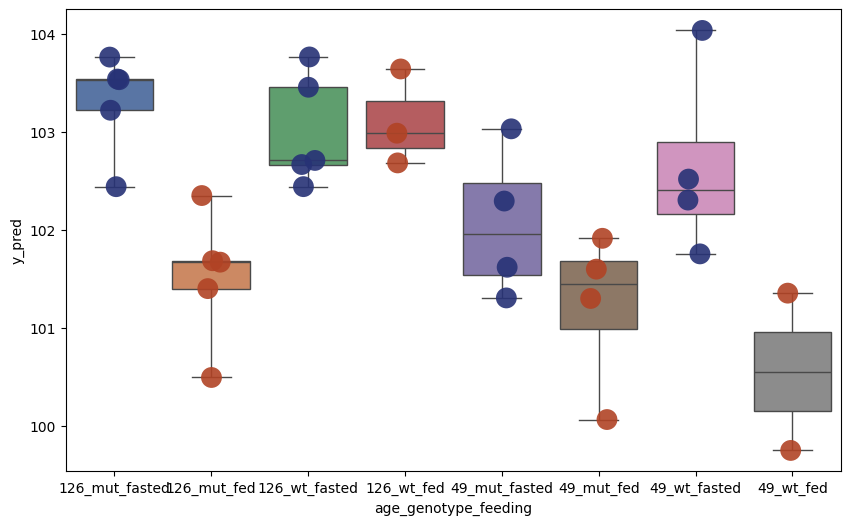

Components: 2
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


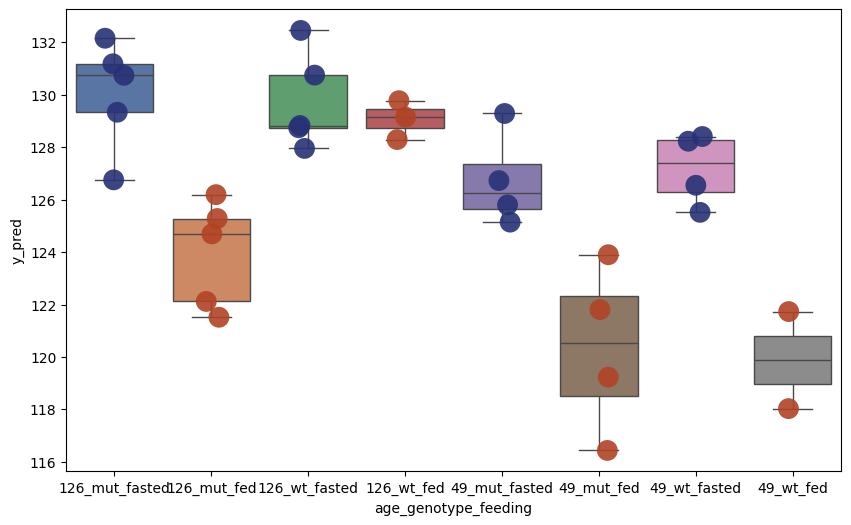

Components: 3
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


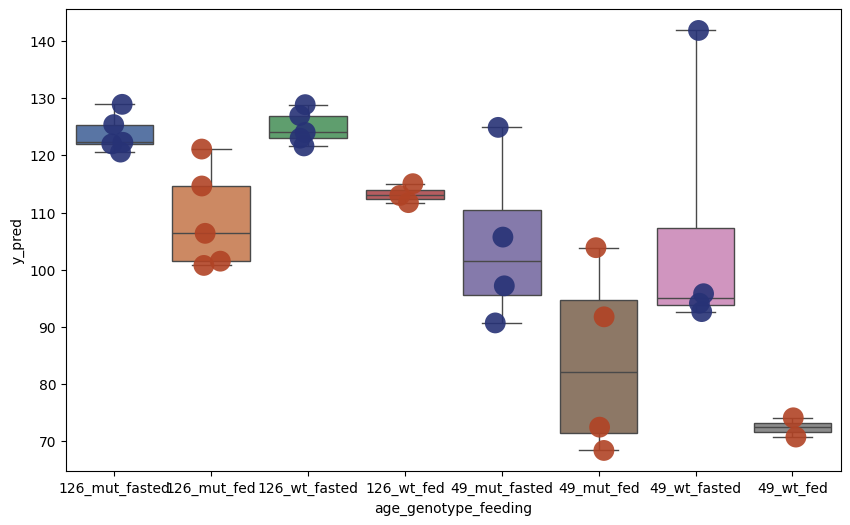

Components: 4
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


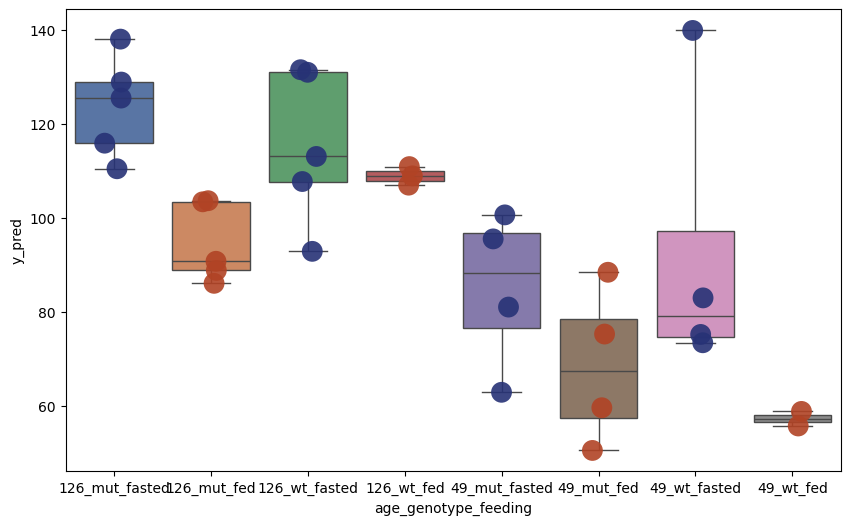

Components: 5
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


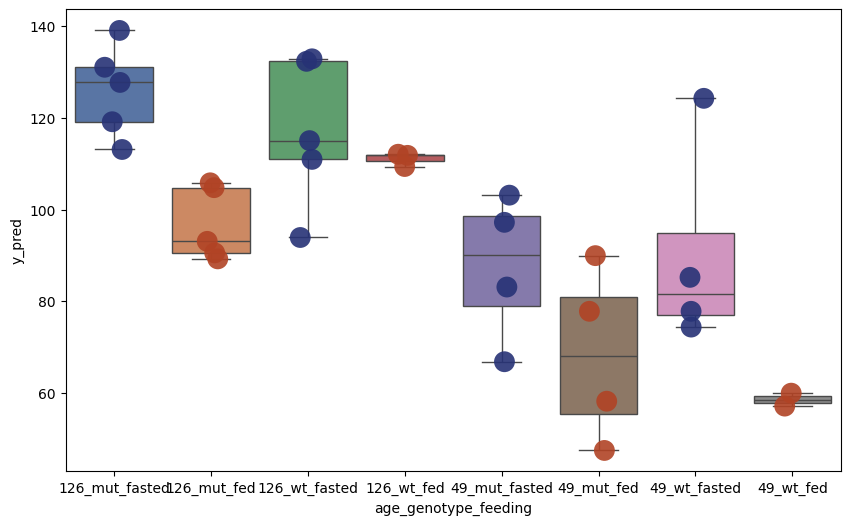

Components: 6
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


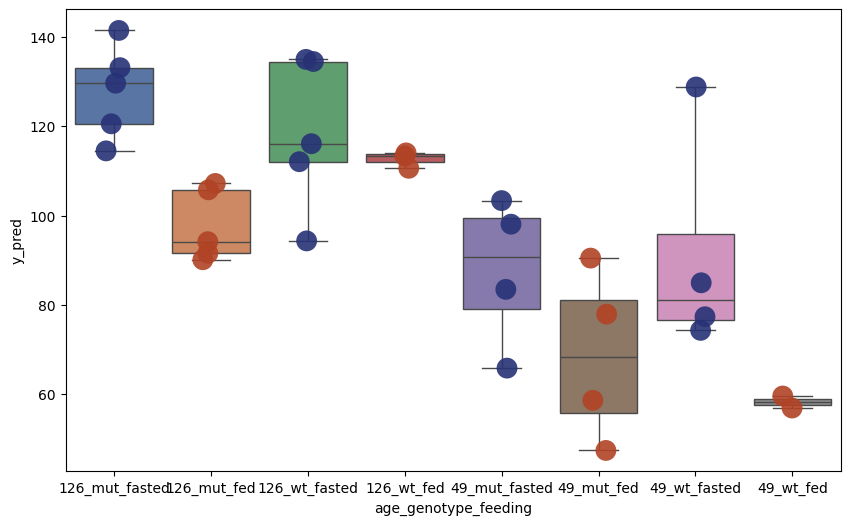

Components: 7
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


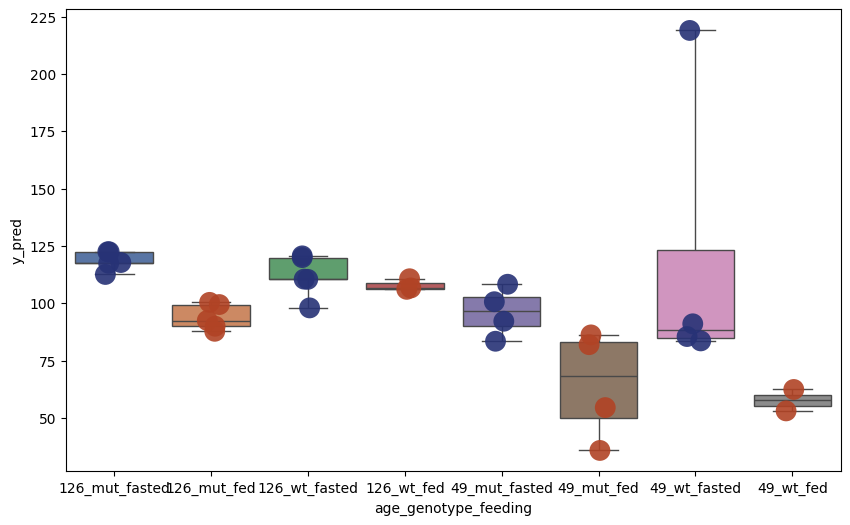

Components: 8
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


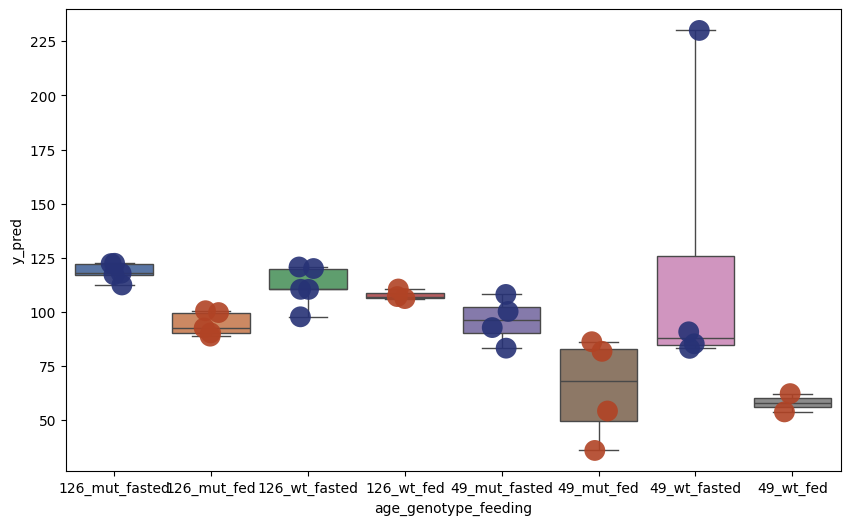

Components: 9
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


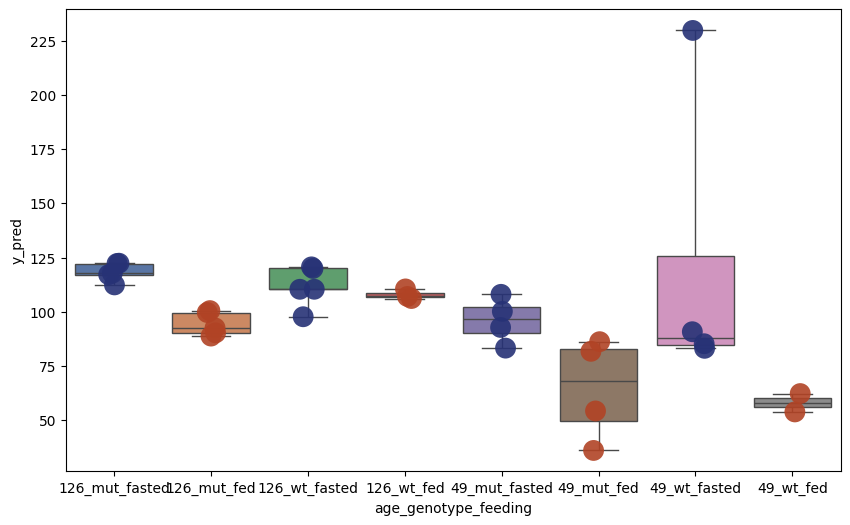

Components: 10
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


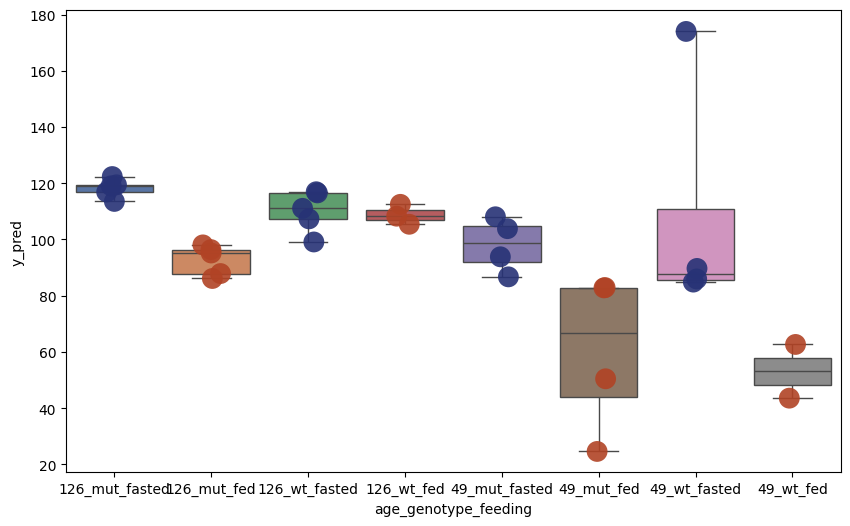

Components: 11
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


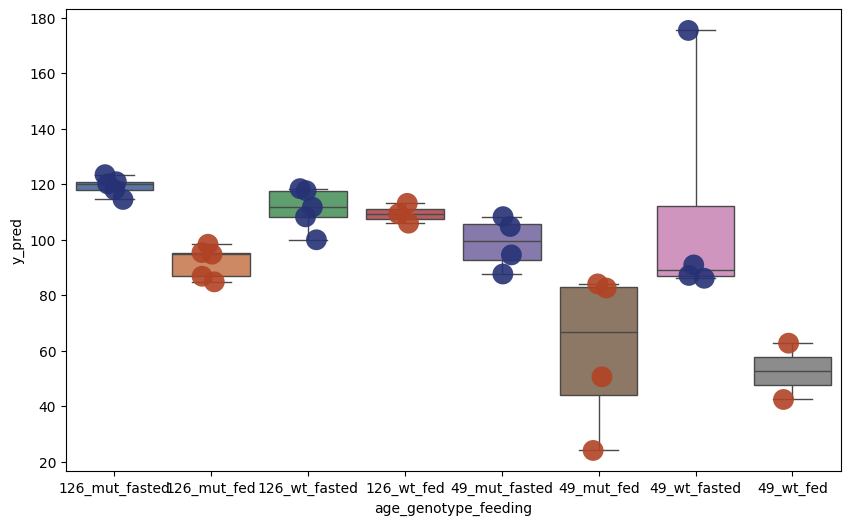

Components: 12
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


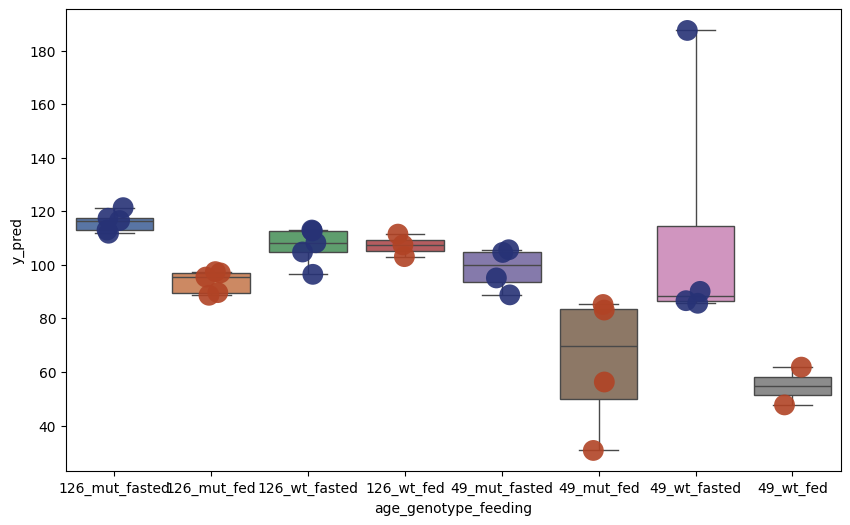

Components: 13
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


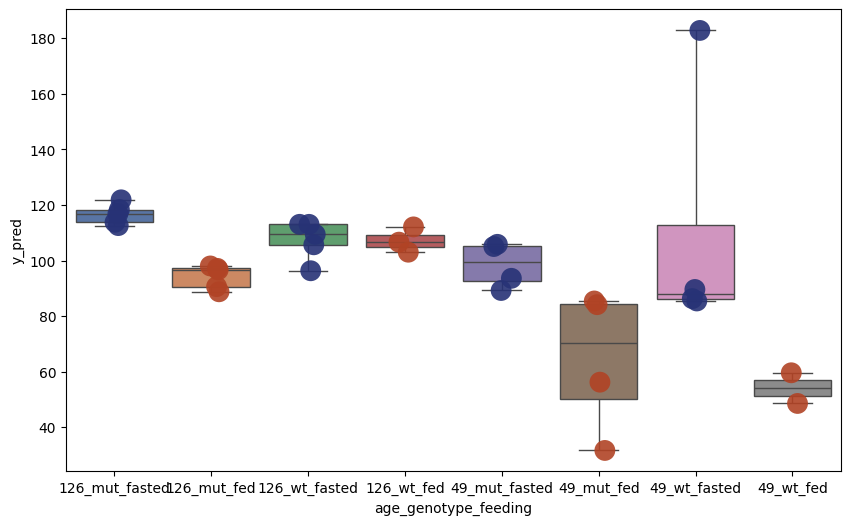

Components: 14
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


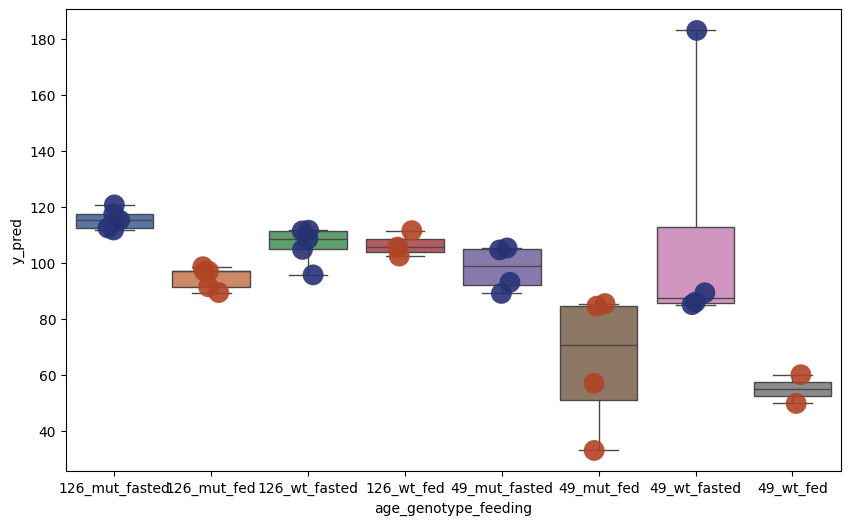

Components: 15
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


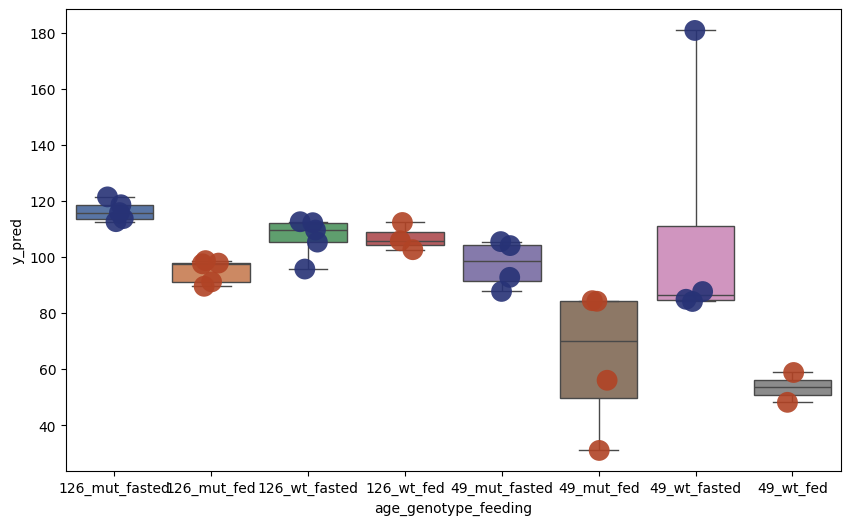

Components: 16
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


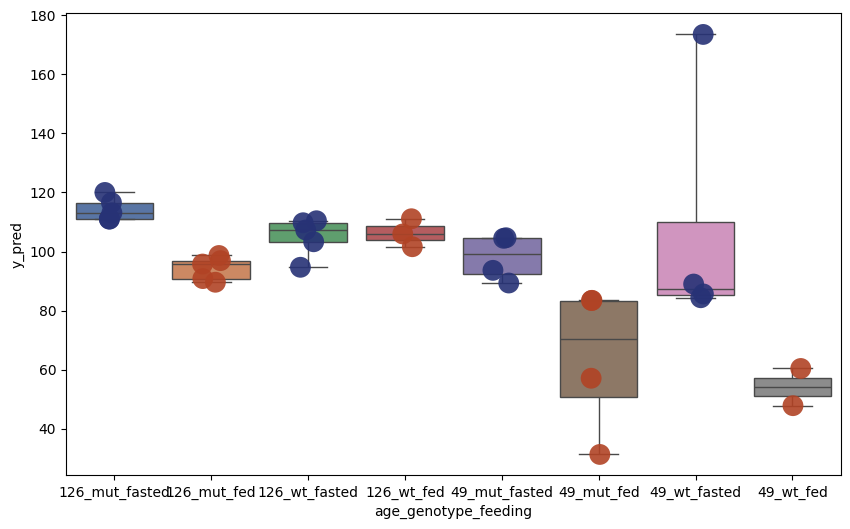

Components: 17
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


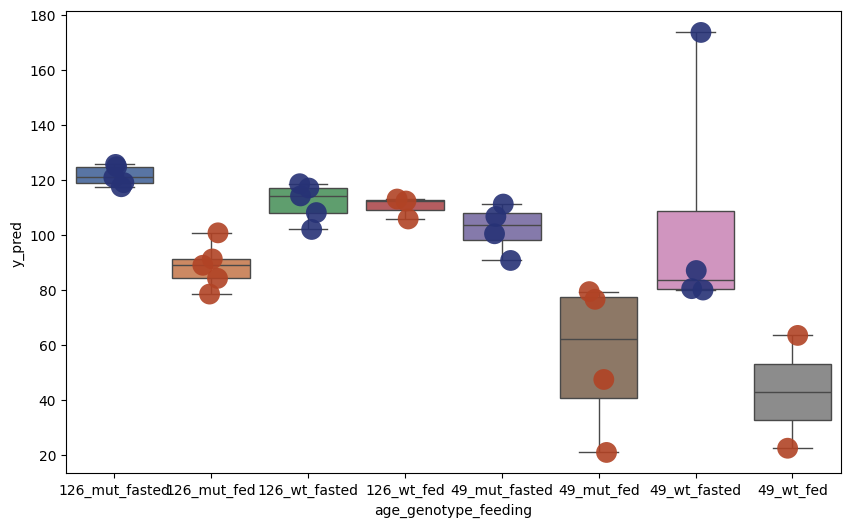

Components: 18
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


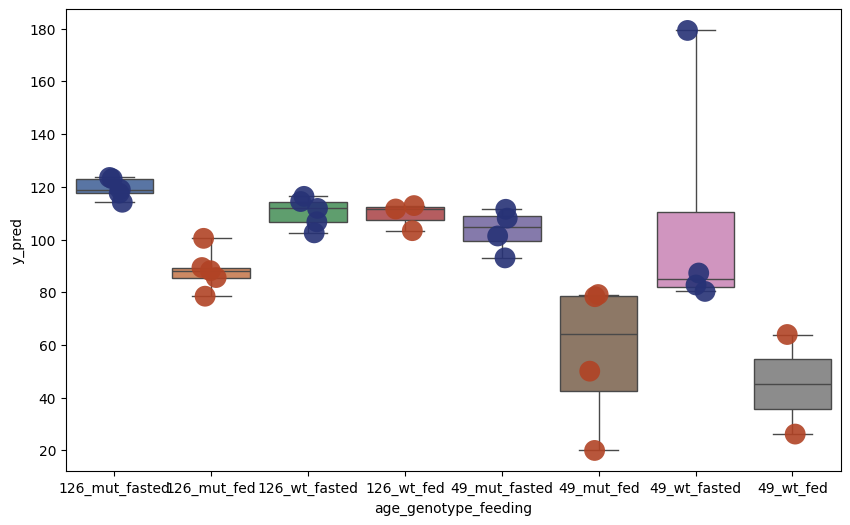

Components: 19
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


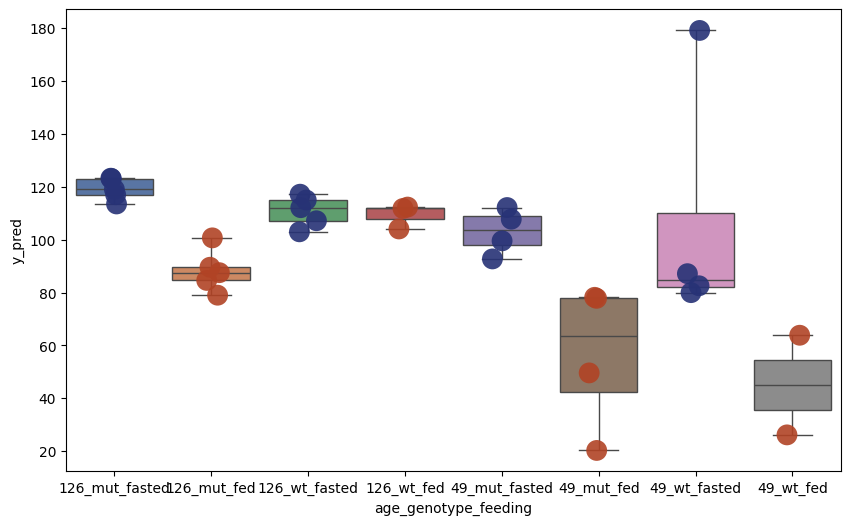

Components: 20
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


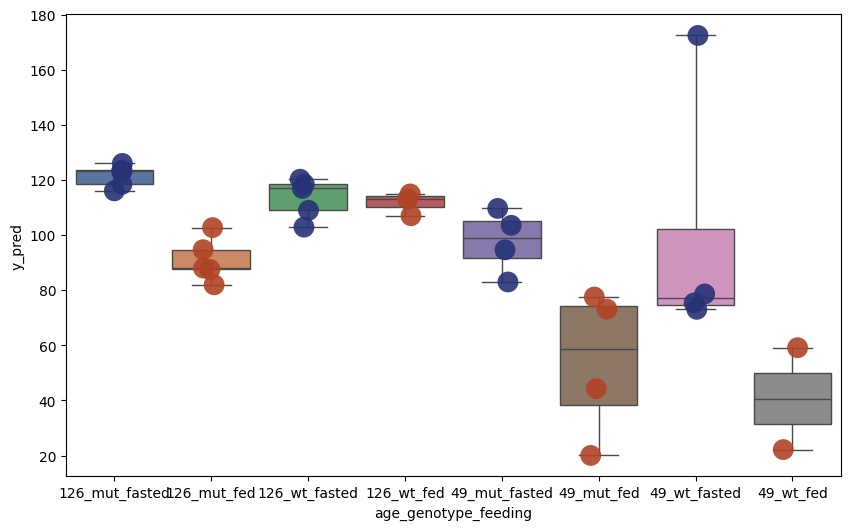

Components: 21
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


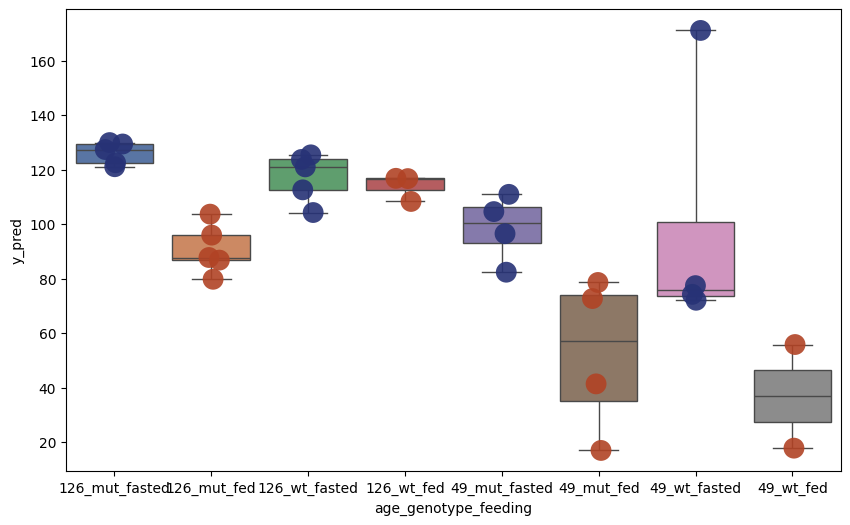

Components: 22
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


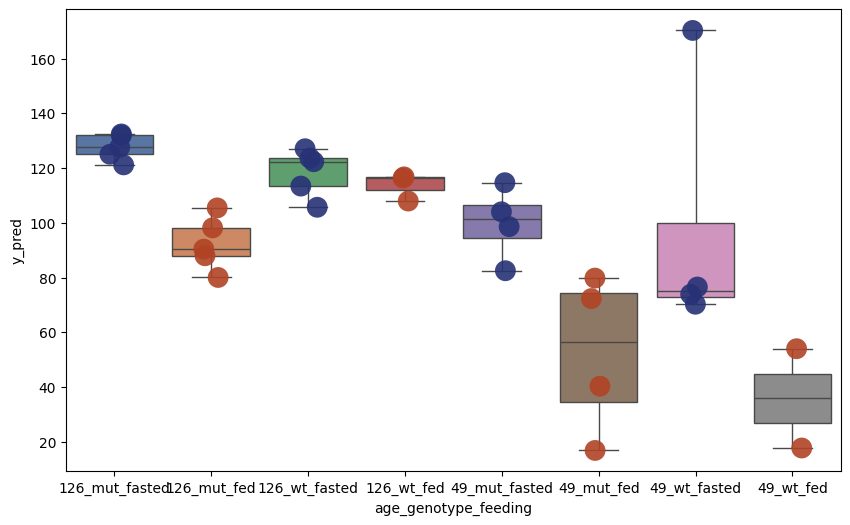

Components: 23
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


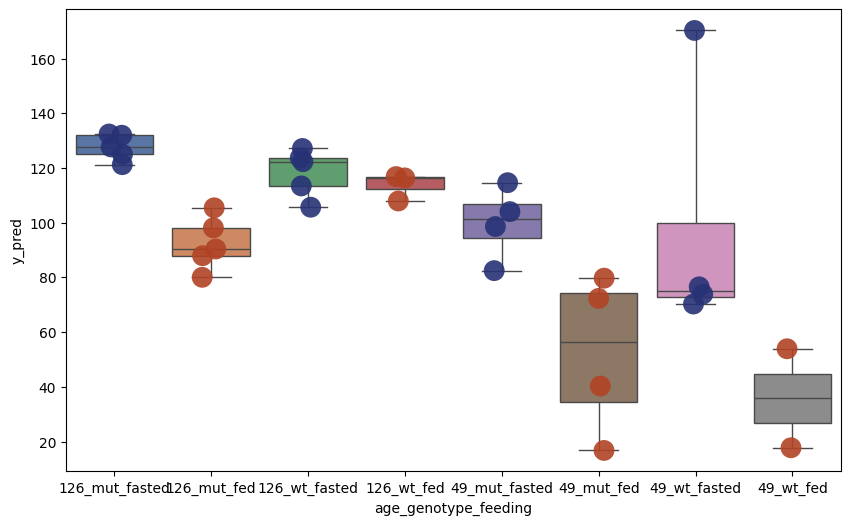

Components: 24
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


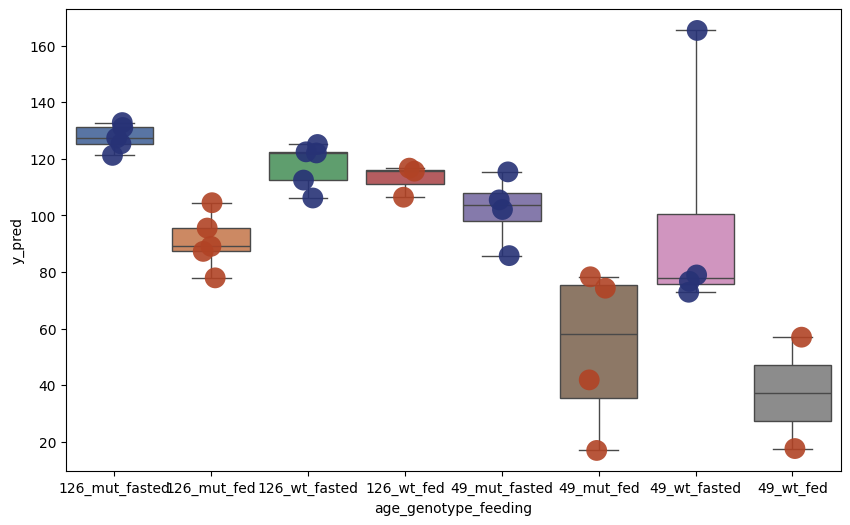

Components: 25
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


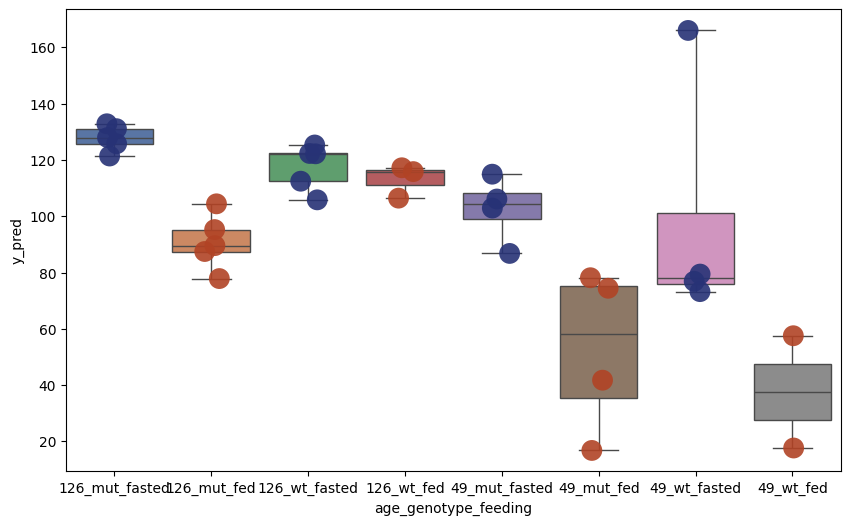

Components: 26
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


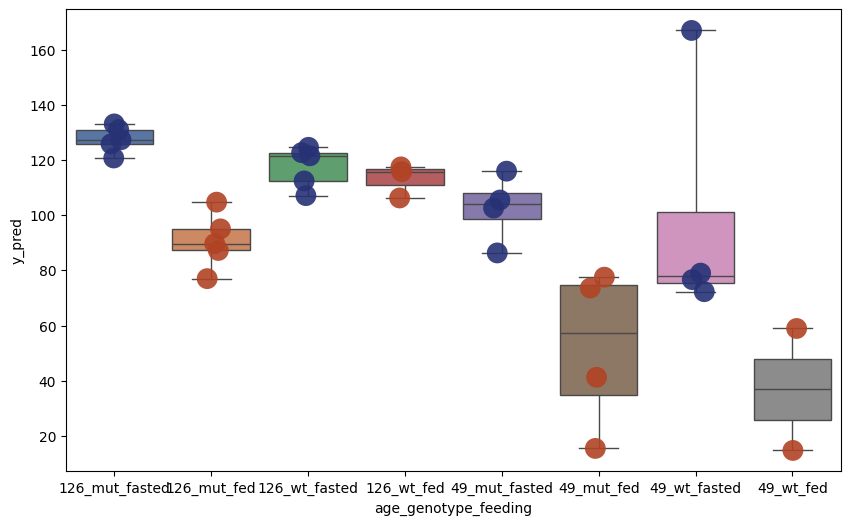

Components: 27
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


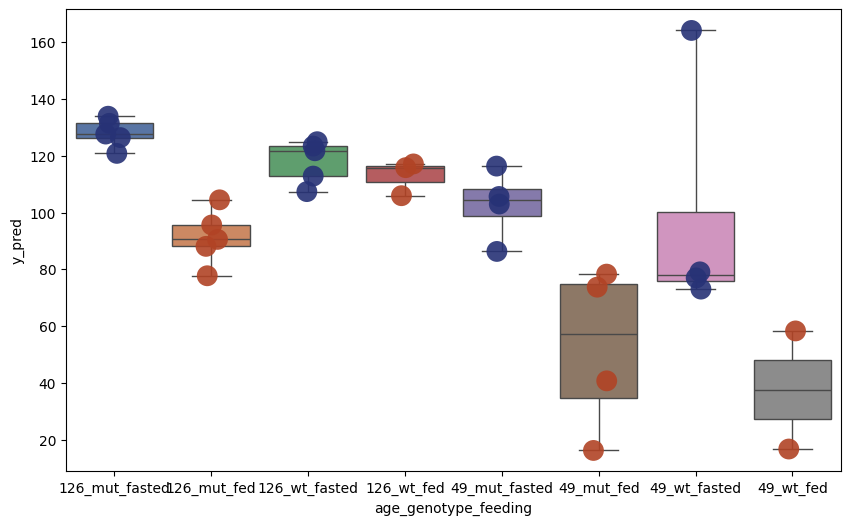

Components: 28
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


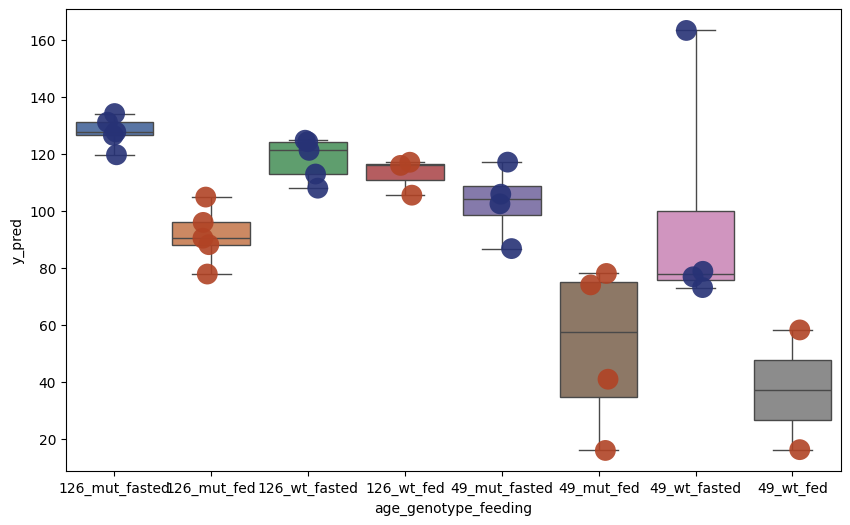

Components: 29
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


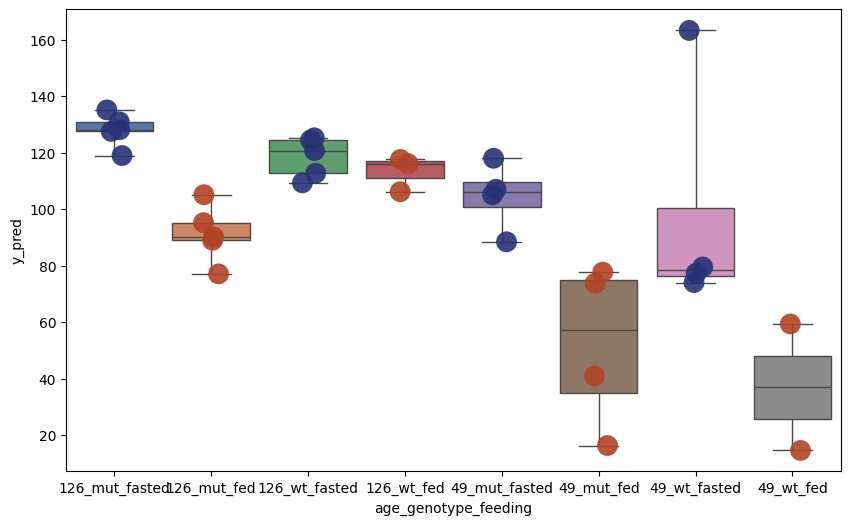

Components: 30
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


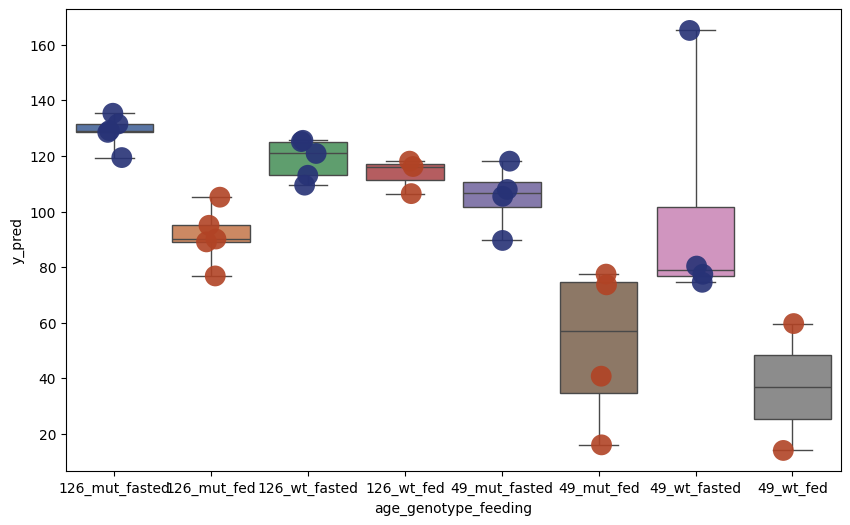

Components: 31
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


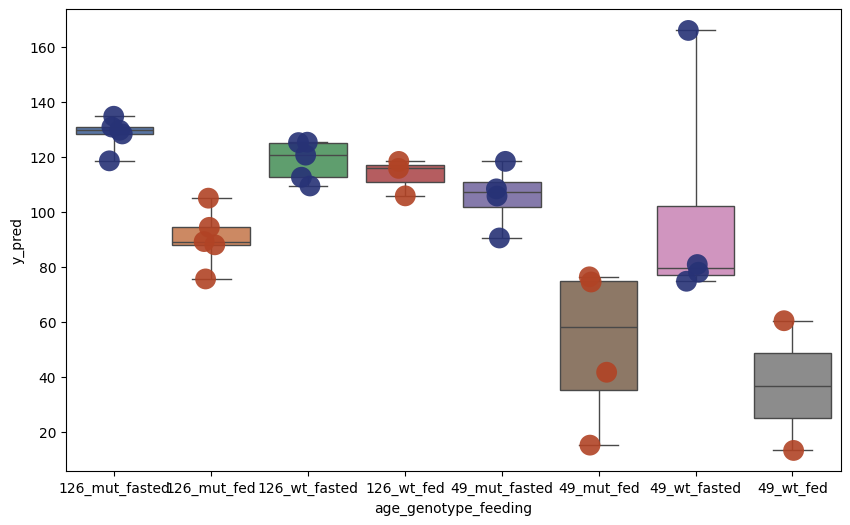

Components: 32
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


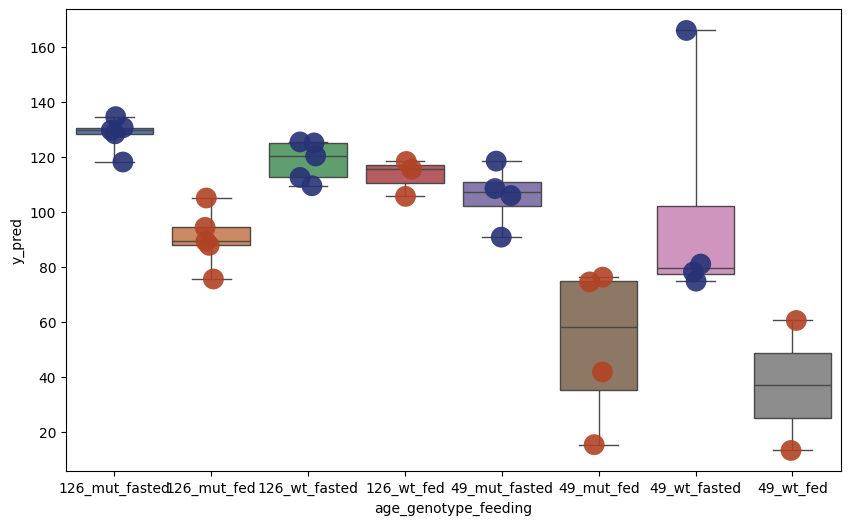

Components: 33
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


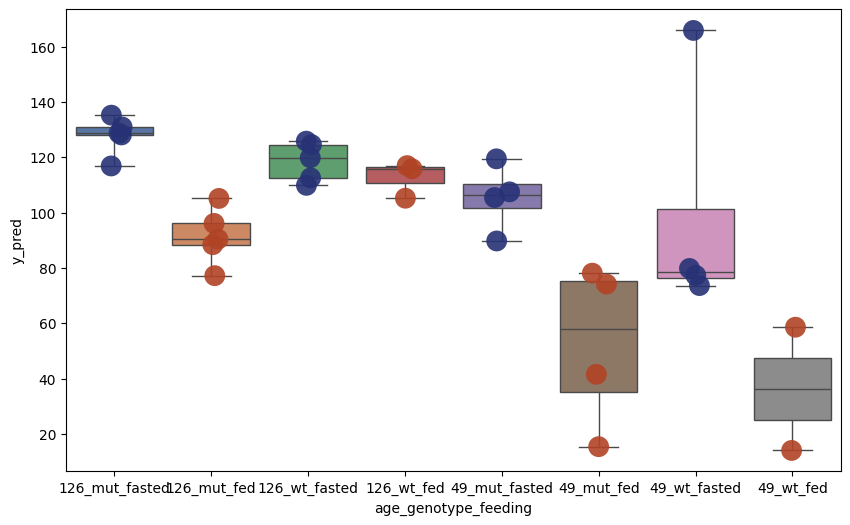

Components: 34
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


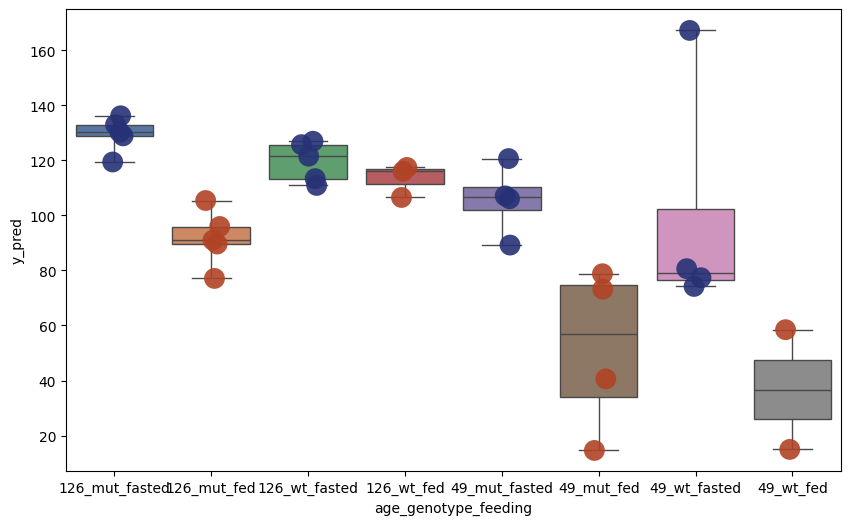

Components: 35
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


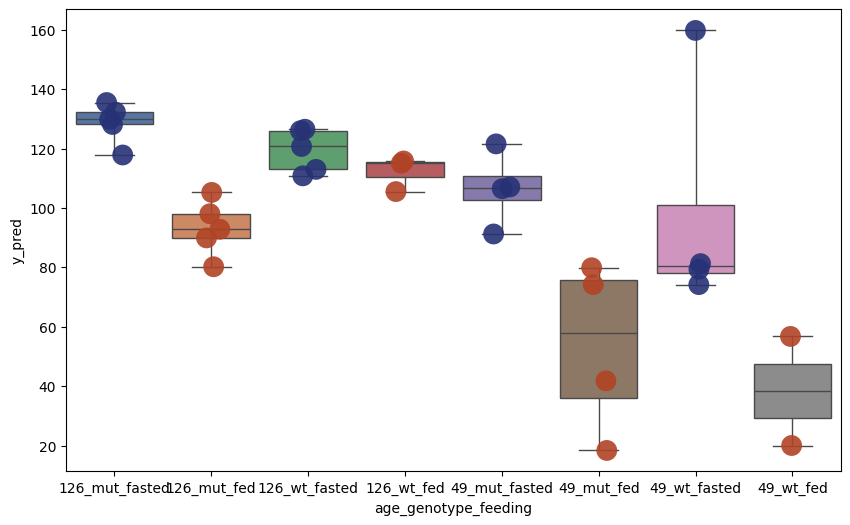

Components: 36
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


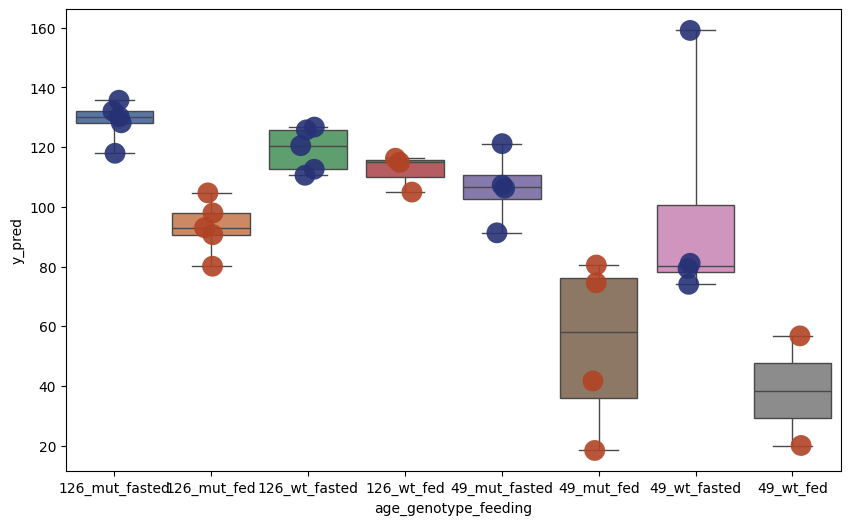

Components: 37
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


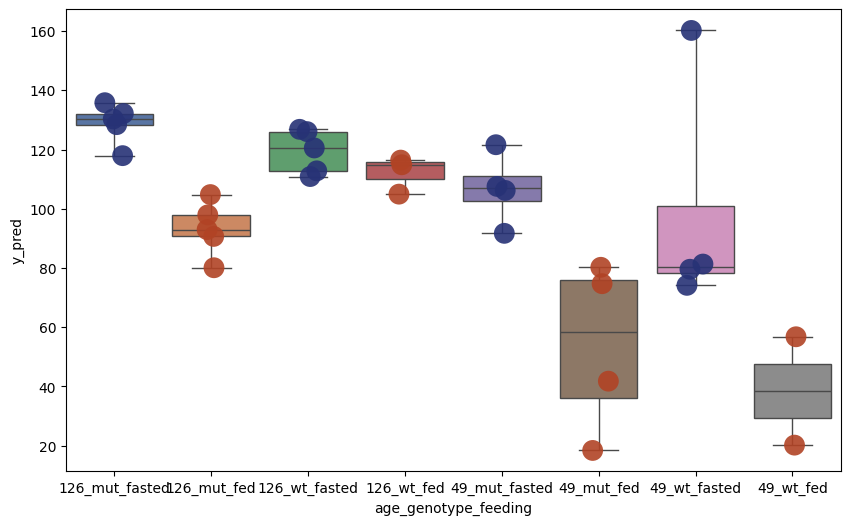

Components: 38
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


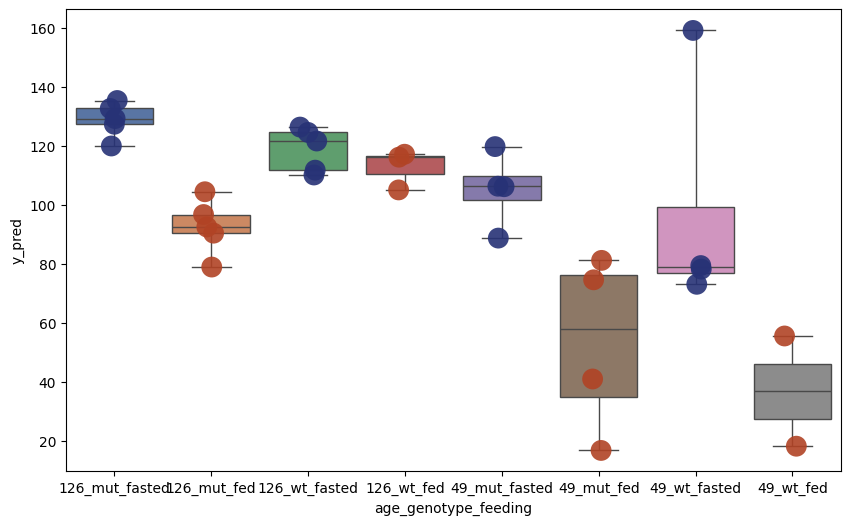

Components: 39
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


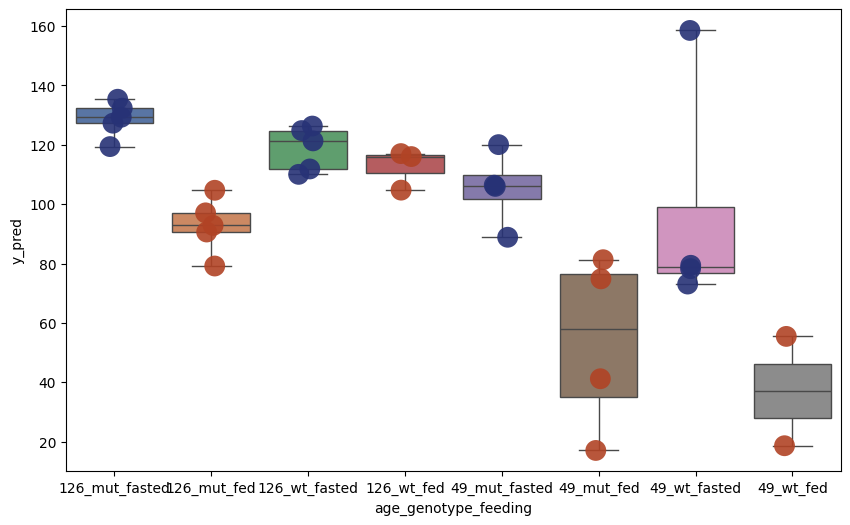

Components: 40
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


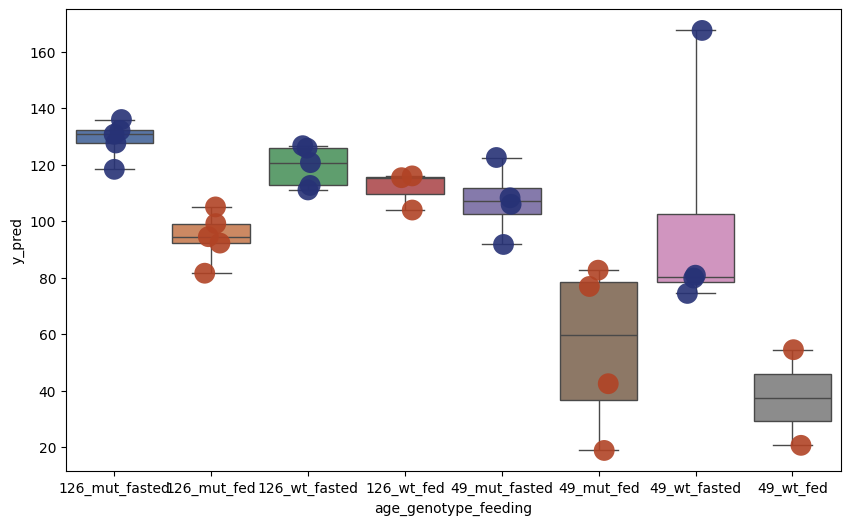

Components: 41
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


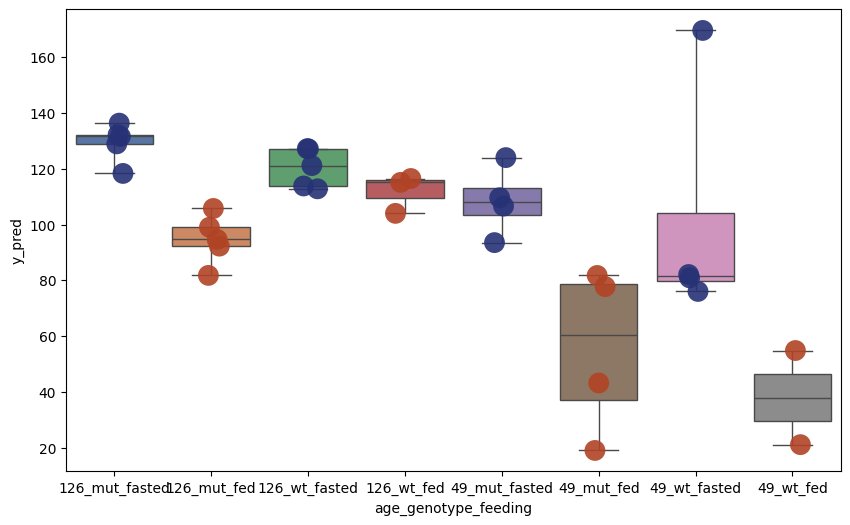

Components: 42
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


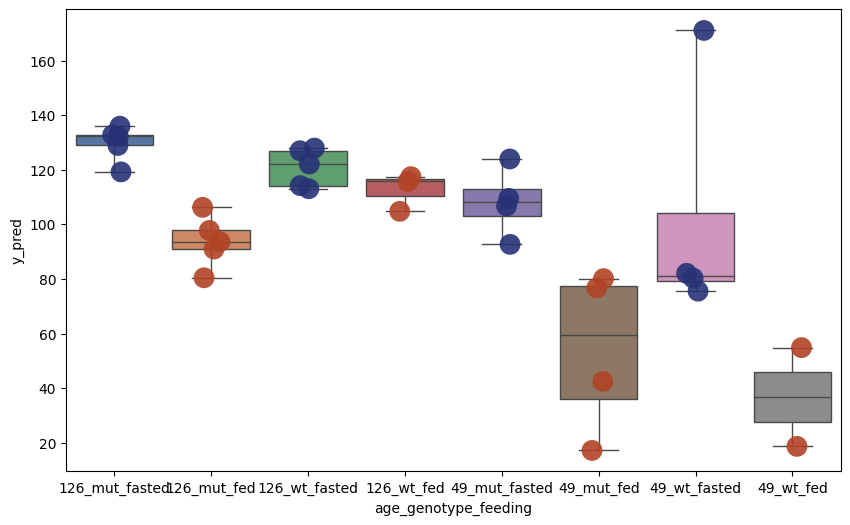

Components: 43
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


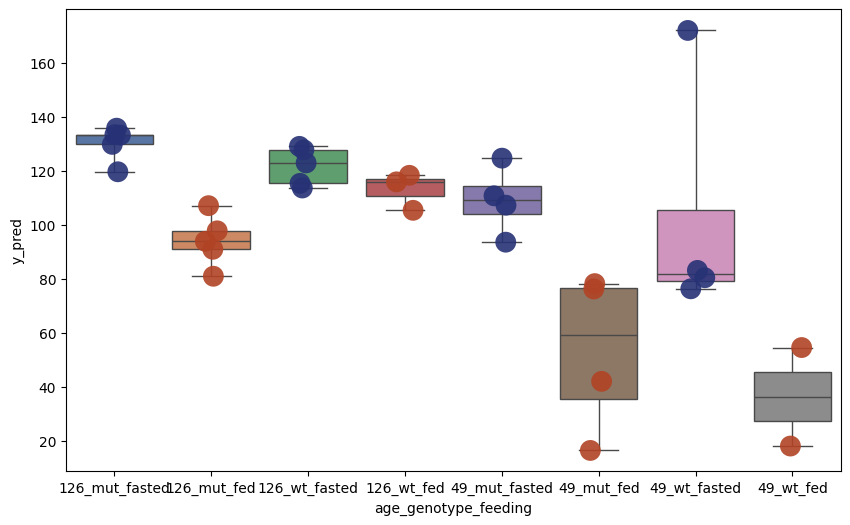

Components: 44
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


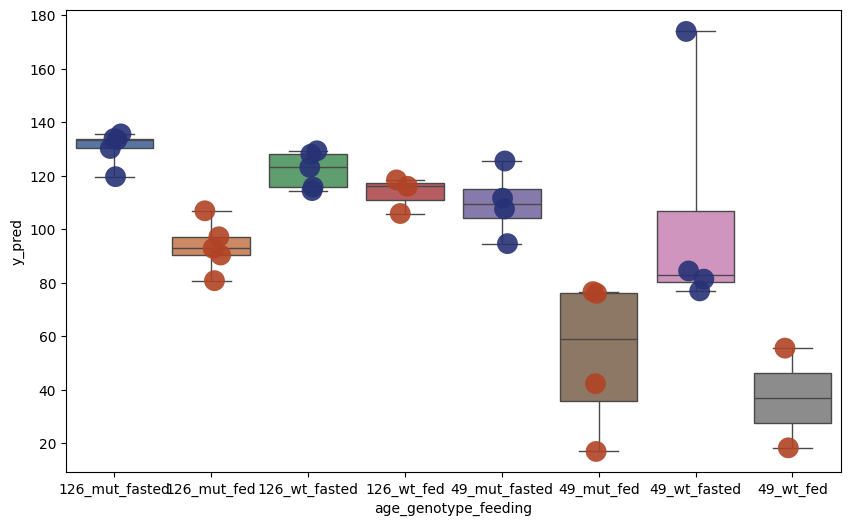

Components: 45
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


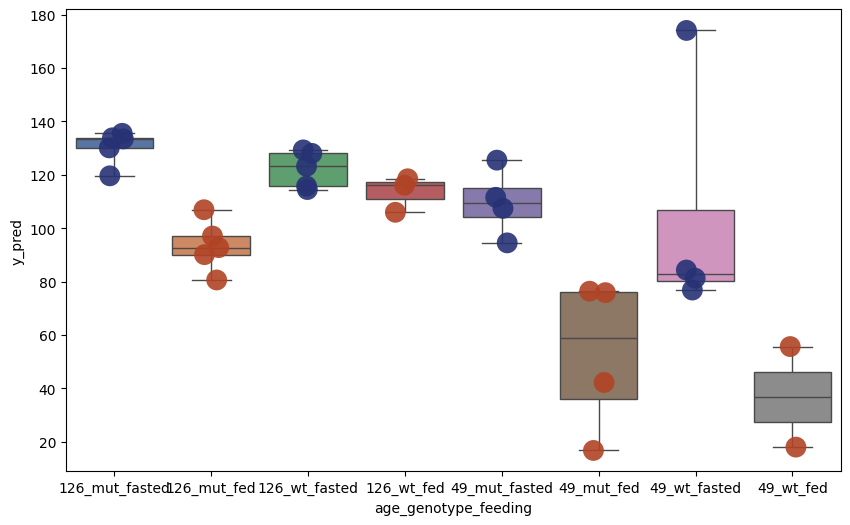

Components: 46
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


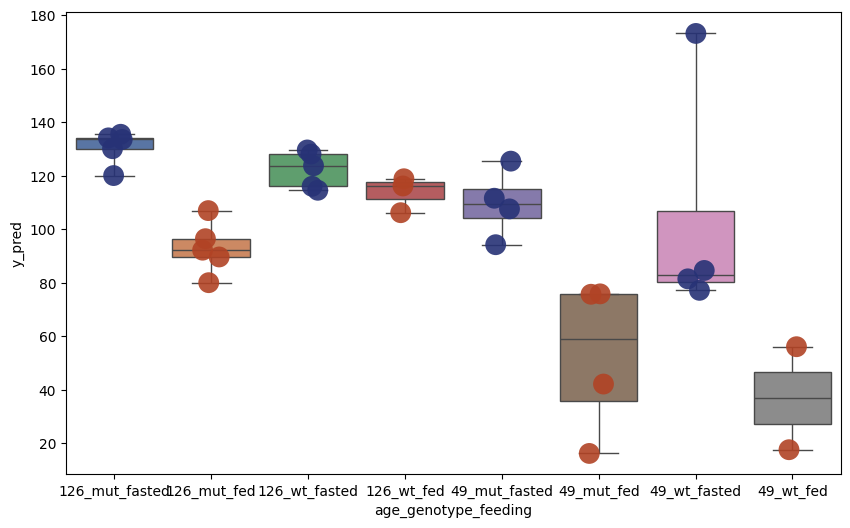

Components: 47
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


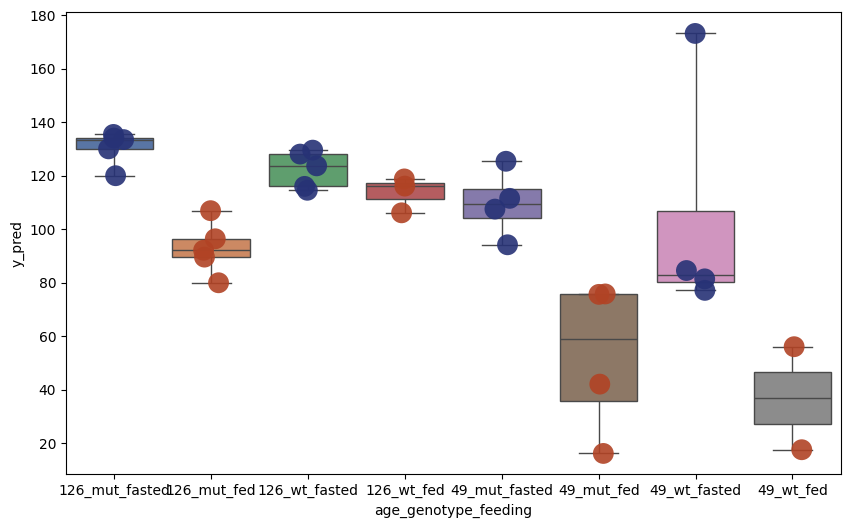

Components: 48
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


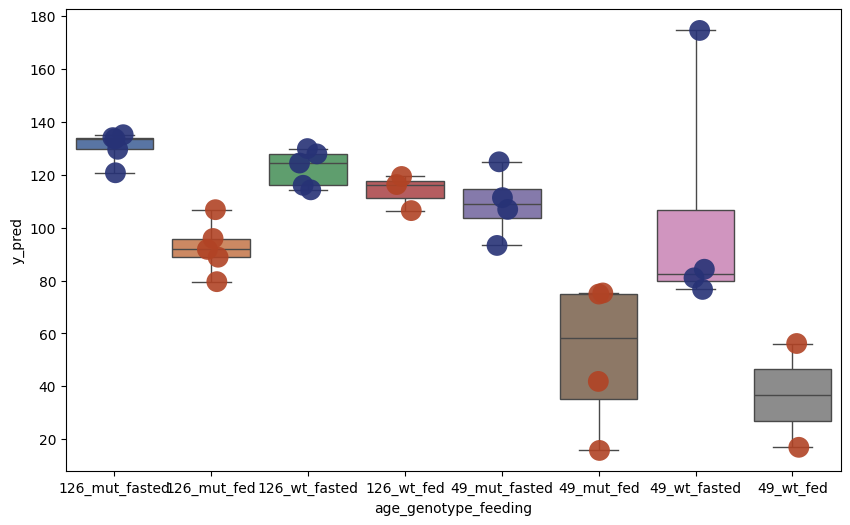

Components: 49
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


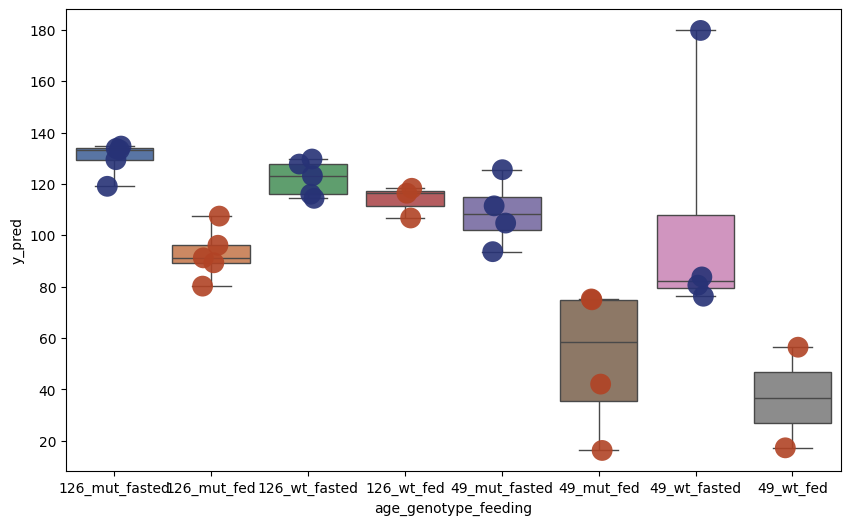

Components: 50
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


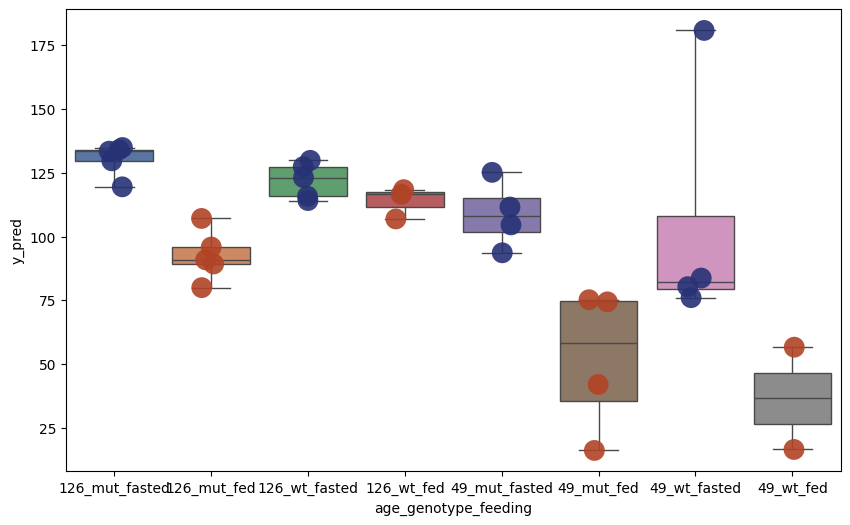

Components: 51
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


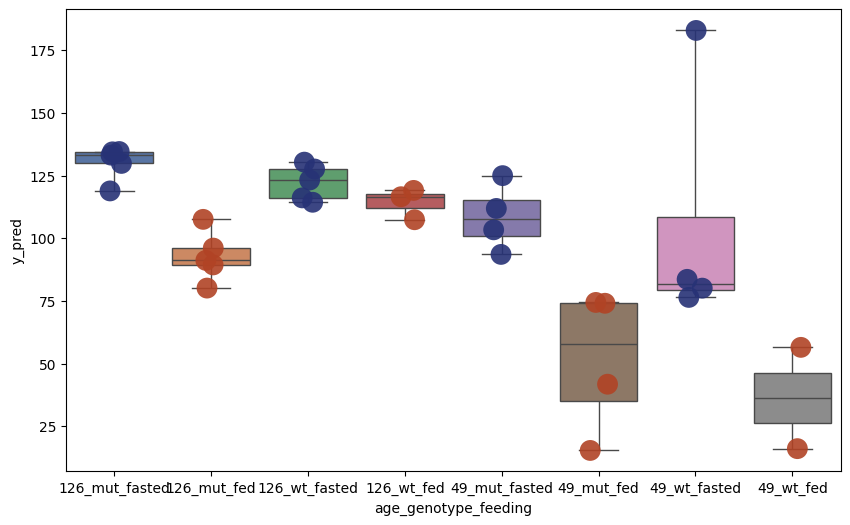

Components: 52
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


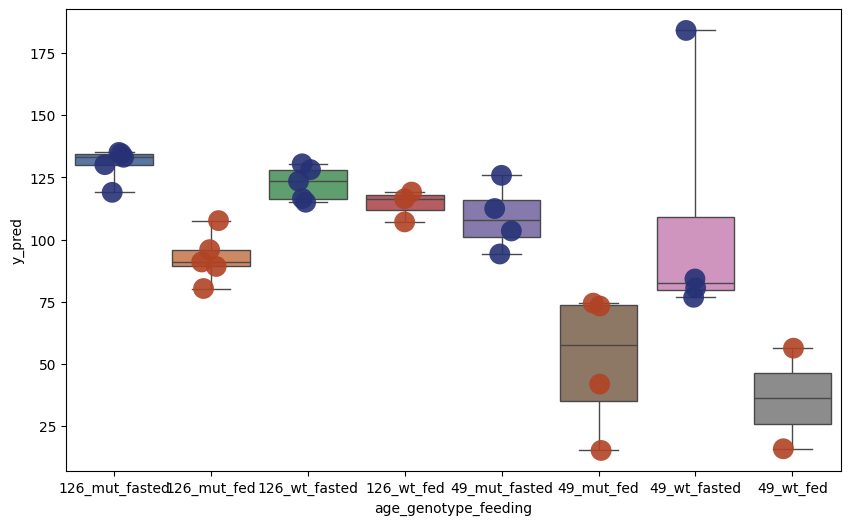

Components: 53
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


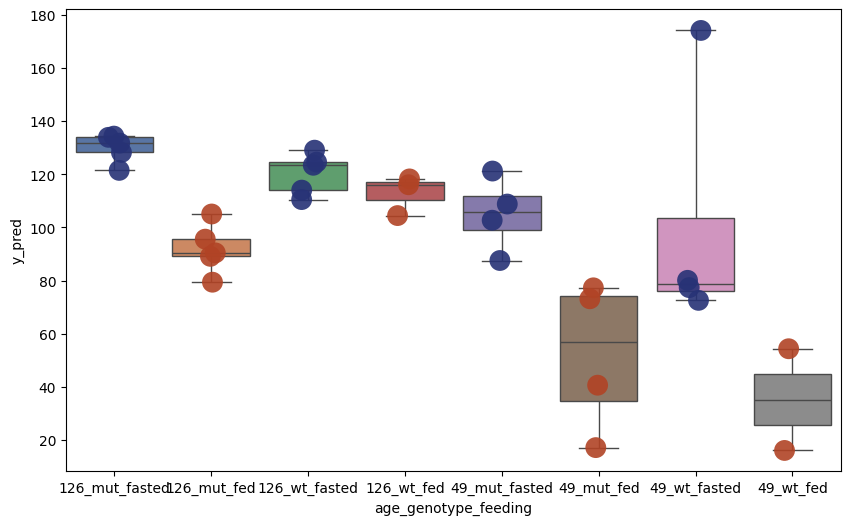

Components: 54
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


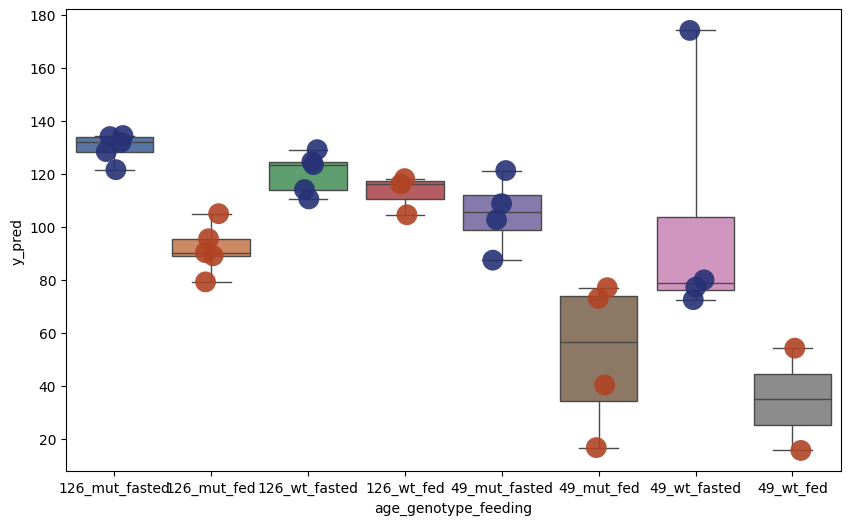

Components: 55
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


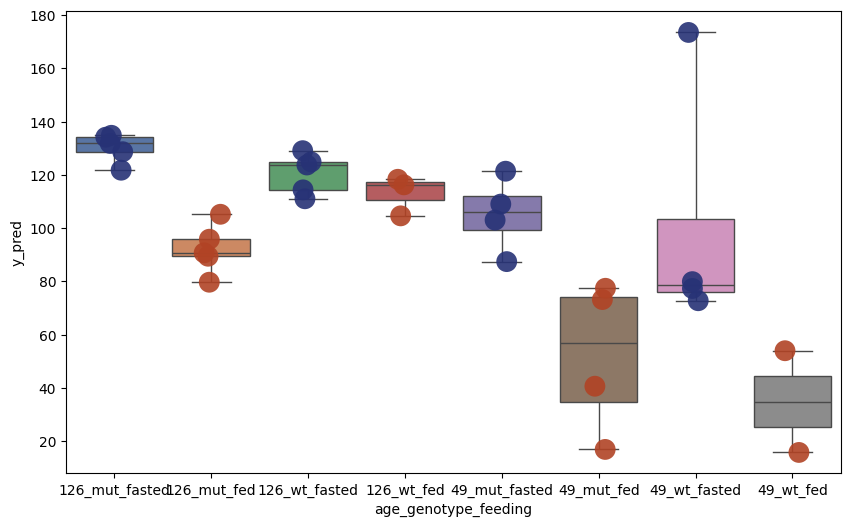

Components: 56
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


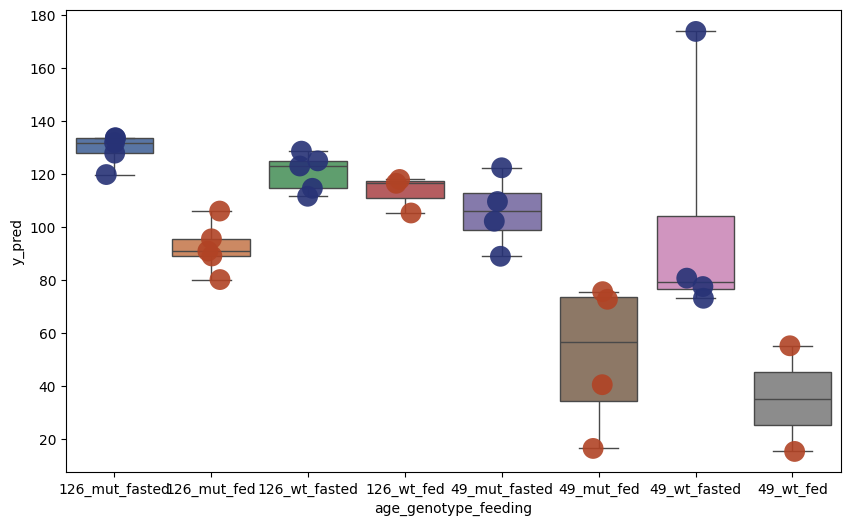

Components: 57
young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fa

/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/local/scratch/emkcosta/slrmtmp.48766815/ipykernel_9569/2735248182.py:53: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


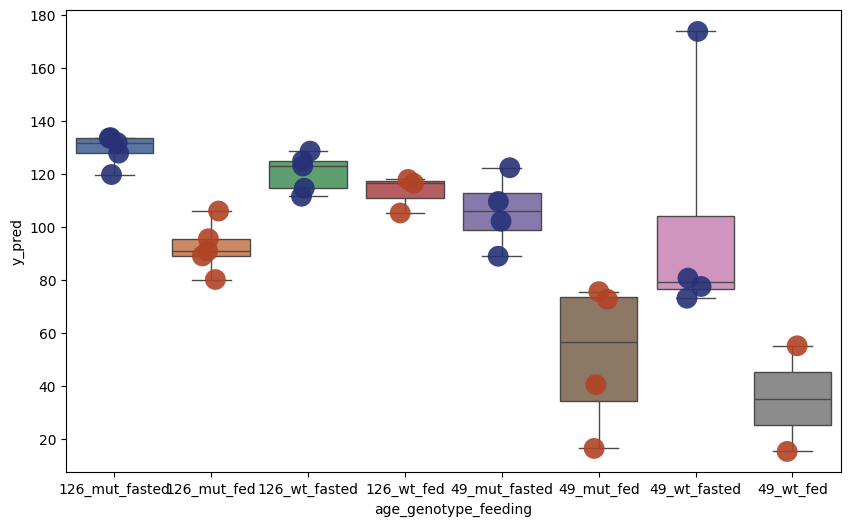

In [57]:
random.seed(123)
# Loop through all possible components to predict the test set
max_components = min(X_train_scaled.shape[0], X_train_scaled.shape[1])
all_y_test_preds = []

for n_components in range(1, max_components + 1):
    print(f"Components: {n_components}")

    # Apply PCA
    pca = PCA(n_components=n_components,svd_solver = 'full', random_state=1)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Train the model
    regressor = LinearRegression()
    regressor.fit(X_train_pca, age_train)

    # Predict on the test set
    y_test_pred = regressor.predict(X_test_pca)

    # Save the actual and predicted values to a DataFrame
    results_df = pd.DataFrame({
    'y_pred': y_test_pred
    }, index=df_intervention_test.index.tolist()) # this should be the test dataset

    df_intervention = results_df.loc[df_intervention_test.index.tolist(), ]

    df_intervention.head(5)

    # Make sure index is treated as string
    sample_names = df_intervention.index.to_series().astype(str)

    print(sample_names)

    # Extract treatment (between first and second period)
    df_intervention["genotype"] = sample_names.str.extract(r'^[^_]+_[^_]+_([^_]+)')
    df_intervention["age"] = df_intervention_test["age"]
    df_intervention["feeding"] = sample_names.str.extract(r'^[^_]+_([^_]+)')
    df_intervention["age_genotype_feeding"] = df_intervention["age"].astype(str) + "_" + df_intervention["genotype"].astype(str)+ "_" + df_intervention["feeding"].astype(str)

    df_intervention = df_intervention.sort_values(by="age_genotype_feeding")

    print(df_intervention)

    # Create the box plot
    plt.figure(figsize=(10, 6))
    box = sns.boxplot(x='age_genotype_feeding', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])

    #custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes
    custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

    # Add data points with custom colors
    strip = sns.stripplot(
        x='age_genotype_feeding',
        y='y_pred',
        data=df_intervention,
        palette=custom_palette,  # Custom color palette
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15
    )

    # # Show the plot
    plt.show()


##### Select PCA num, export to csv

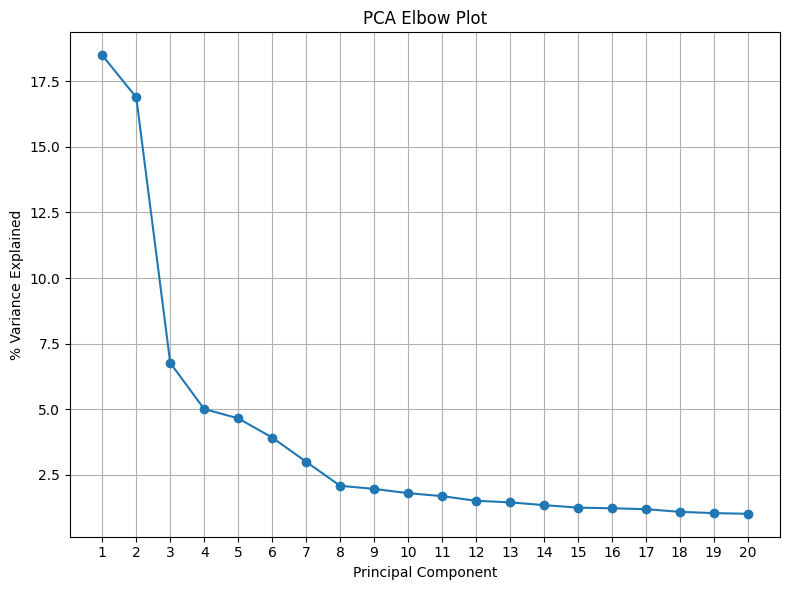

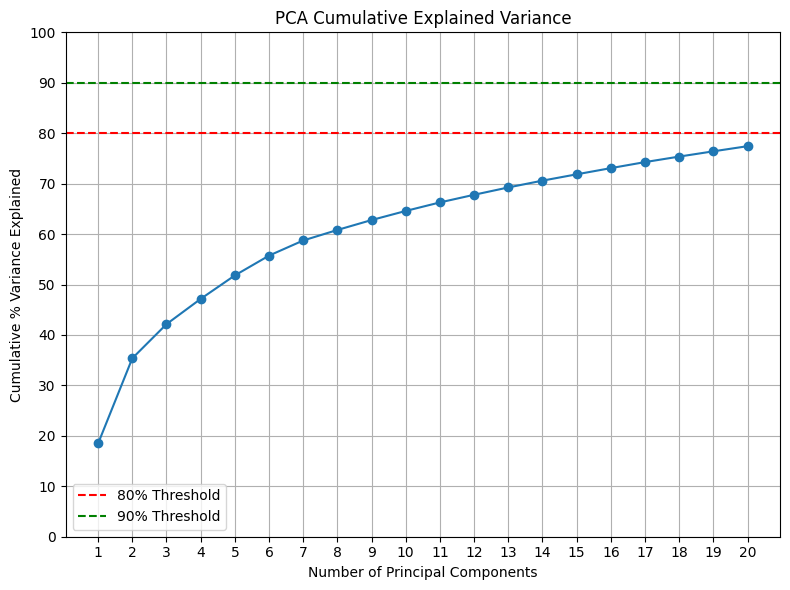

In [62]:
n_components = 20

# Apply PCA
pca = PCA(n_components=n_components, svd_solver = 'full', random_state=1)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot elbow plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance * 100, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('% Variance Explained')
plt.title('PCA Elbow Plot')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100  # in %

# Plot cumulative explained variance (elbow plot)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative % Variance Explained')
plt.title('PCA Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.yticks(np.arange(0, 110, 10))
plt.axhline(y=80, color='red', linestyle='--', label='80% Threshold')
plt.axhline(y=90, color='green', linestyle='--', label='90% Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
n_components = 11

# Apply PCA
pca = PCA(n_components=n_components, svd_solver = 'full', random_state=1)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train the model
regressor = LinearRegression()
regressor.fit(X_train_pca, age_train)

# Predict on the test set
y_test_pred = regressor.predict(X_test_pca)

# Save the actual and predicted values to a DataFrame
results_df = pd.DataFrame({
'y_pred': y_test_pred
}, index=df_intervention_test.index.tolist()) # this should be the test dataset

df_intervention = results_df.loc[df_intervention_test.index.tolist(), ]

df_intervention.head(5)

# Make sure index is treated as string
sample_names = df_intervention.index.to_series().astype(str)

print(sample_names)

# Extract treatment (between first and second period)
df_intervention["genotype"] = sample_names.str.extract(r'^[^_]+_[^_]+_([^_]+)')
df_intervention["age"] = df_intervention_test["age"]
df_intervention["feeding"] = sample_names.str.extract(r'^[^_]+_([^_]+)')
df_intervention["age_genotype_feeding"] = df_intervention["age"].astype(str) + "_" + df_intervention["genotype"].astype(str)+ "_" + df_intervention["feeding"].astype(str)

df_intervention = df_intervention.sort_values(by="age_genotype_feeding")

print(df_intervention)
df_intervention.to_csv("./predictions/Antebi_fat_sexcombo_predictions_11PCs_EC-250723.csv")


young_fed_wt_fat_rep_4            young_fed_wt_fat_rep_4
young_fasted_wt_fat_rep_1      young_fasted_wt_fat_rep_1
young_fasted_wt_fat_rep_2      young_fasted_wt_fat_rep_2
young_fasted_wt_fat_rep_3      young_fasted_wt_fat_rep_3
young_fasted_wt_fat_rep_4      young_fasted_wt_fat_rep_4
young_fed_mut_fat_rep_1          young_fed_mut_fat_rep_1
young_fed_mut_fat_rep_2          young_fed_mut_fat_rep_2
young_fed_mut_fat_rep_3          young_fed_mut_fat_rep_3
young_fed_mut_fat_rep_4          young_fed_mut_fat_rep_4
young_fasted_mut_fat_rep_1    young_fasted_mut_fat_rep_1
young_fasted_mut_fat_rep_2    young_fasted_mut_fat_rep_2
young_fasted_mut_fat_rep_3    young_fasted_mut_fat_rep_3
young_fasted_mut_fat_rep_4    young_fasted_mut_fat_rep_4
old_fed_wt_fat_rep_5                old_fed_wt_fat_rep_5
old_fasted_wt_fat_rep_1          old_fasted_wt_fat_rep_1
old_fasted_wt_fat_rep_2          old_fasted_wt_fat_rep_2
old_fasted_wt_fat_rep_3          old_fasted_wt_fat_rep_3
old_fasted_wt_fat_rep_4        

# Rotate Training Samples

In [51]:
# --------------------------------------------------------------------
# Config
# --------------------------------------------------------------------
OUTDIR = "./predictions_exhaustive"
os.makedirs(OUTDIR, exist_ok=True)

# If you want to cap PCs to a smaller number (e.g., 100), set here; else leave None to use full allowable range
PC_CAP = 20   # e.g., PC_CAP = 100

# --------------------------------------------------------------------
# Sample selection setup (same as your BayesAge loop)
# --------------------------------------------------------------------
WT_samples = df_intervention_age[df_intervention_age['genotype'] == 'GRZ_AD wild_type'].index

#get rid of fed samples, remove the test samples that have "fasted" in the name
WT_samples = [s for s in WT_samples if 'fasted' not in s.lower()]
WT_samples = sorted(WT_samples)

young_samples = [s for s in WT_samples if s.startswith("young")]
old_samples = [s for s in WT_samples if s.startswith("old")]

# All 2x2 combinations
young_combos = list(itertools.combinations(young_samples, 2))
old_combos   = list(itertools.combinations(old_samples, 2))

In [53]:
random.seed(123)
# --------------------------------------------------------------------
# Main loop: iterate over all combos, then sweep PC numbers
# --------------------------------------------------------------------
for y_combo in young_combos:
    for o_combo in old_combos:

        combo_id = f"{'_'.join(map(str, y_combo))}__{'_'.join(map(str, o_combo))}"
        print(f"\nRunning PCR for combo: {combo_id}")

        # ----------------------------
        # Build TRAIN/ATLAS combined
        # ----------------------------
        select_train_samples = list(y_combo) + list(o_combo)

        df_intervention_train_full = df_intervention_age.loc[select_train_samples]

        # Use tissue_df_age (counts + age + meta) for atlas, then append intervention rows
        atlas_plus_intervention = pd.concat([tissue_df_age, df_intervention_train_full], axis=0)

        # Age target (pull BEFORE dropping meta columns)
        y_train_age = atlas_plus_intervention['age'].astype(float)

        # Training features: drop metadata columns by your index pattern
        X_train_counts = atlas_plus_intervention.drop(
            atlas_plus_intervention.columns[[-1,-2, -3, -4, -5, -6]], axis=1
        )

        # ----------------------------
        # Build TEST matrices/metadata
        # ----------------------------
        test_samples = [s for s in df_intervention_age.index if s not in select_train_samples]
        df_intervention_test_full = df_intervention_age.loc[test_samples]

        # Drop the same metadata columns for TEST and align to train columns
        X_test_counts = df_intervention_test_full.drop(
            df_intervention_test_full.columns[[-1,-2, -3, -4,-5, -6]], axis=1
        )
        X_test_counts = X_test_counts[X_train_counts.columns]

        # Test metadata for annotations
        test_meta = df_intervention_age.loc[
            test_samples, ['genotype', 'age']
        ].copy()

        # ----------------------------
        # Scale and PCR
        # ----------------------------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_counts.values)
        X_test_scaled  = scaler.transform(X_test_counts.values)

        # Determine allowable PCs
        max_components_allowed = min(X_train_scaled.shape[0], X_train_scaled.shape[1])
        if PC_CAP is not None:
            max_components_allowed = min(max_components_allowed, PC_CAP)

        for n_components in range(1, max_components_allowed + 1):
            print(f"  PCs: {n_components}")

            # PCA on training, transform both
            pca = PCA(n_components=n_components,svd_solver = 'full', random_state=1)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_test_pca  = pca.transform(X_test_scaled)

            # Linear regression on PCs → age
            regressor = LinearRegression()
            regressor.fit(X_train_pca, y_train_age.values)

            # Predict for test samples
            y_test_pred = regressor.predict(X_test_pca)

            # Package output with metadata
            df_pred = pd.DataFrame({'y_pred': y_test_pred}, index=test_samples)
            df_pred = df_pred.join(test_meta, how='left').sort_values(by="age")

            # Save
            out_prefix = f"PCR_pred_{combo_id}_pc{n_components:03d}"
            out_path = os.path.join(OUTDIR, f"{out_prefix}.tsv")
            df_pred.to_csv(out_path, sep="\t")



Running PCR for combo: young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_2
  PCs: 1
  PCs: 2
  PCs: 3
  PCs: 4
  PCs: 5
  PCs: 6
  PCs: 7
  PCs: 8
  PCs: 9
  PCs: 10
  PCs: 11
  PCs: 12
  PCs: 13
  PCs: 14
  PCs: 15
  PCs: 16
  PCs: 17
  PCs: 18
  PCs: 19
  PCs: 20

Running PCR for combo: young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_3
  PCs: 1
  PCs: 2
  PCs: 3
  PCs: 4
  PCs: 5
  PCs: 6
  PCs: 7
  PCs: 8
  PCs: 9
  PCs: 10
  PCs: 11
  PCs: 12
  PCs: 13
  PCs: 14
  PCs: 15
  PCs: 16
  PCs: 17
  PCs: 18
  PCs: 19
  PCs: 20

Running PCR for combo: young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_4
  PCs: 1
  PCs: 2
  PCs: 3
  PCs: 4
  PCs: 5
  PCs: 6
  PCs: 7
  PCs: 8
  PCs: 9
  PCs: 10
  PCs: 11
  PCs: 12
  PCs: 13
  PCs: 14
  PCs: 15
  PCs: 16
  PCs: 17
  PCs: 18
  PCs: 19
  PCs: 20

Running PCR for combo: young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_re